In [2]:
# Comparison script

# 1.1 --- Importing packages ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory
from Tracer.solvers import solver_rk45, solver_euler

# play field parameters - these make up the baseline shot
P0=np.array([0, 0, 0])
nx = 500        # length of play field
ny = 200        # width of play field
nz = 100        # height of play field
dt = 0.01       # time step

# Basis shot parameters - if not otherwise specified, these are used
shot_speed = 76.44384   # intital velocity
shot_angle = 10.4       # initial angle for trajectory	
shot_spin = 2545        # initial spin
spin_axis = 0           # spin axis adding impurity to the spin
orientation = 0         # play direction

# Basis wind parameters - if not otherwise specified, these are used
U_ref = 6      # reference wind speed at 10 meters above ground (6 m/s is approx. danish average)
z0 = 0.03       # surface roughness
direction = 0   # wind direction (0 is tailwind, 180 is headwind)

# script parameters
design_n = 10           # design parameter for # of values in design library
r = 150                 # Approximate radius of playfield, used for rotation and movement of player position

# filepaths for RANS simulations with varying z0
datafile01 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.001_mb_cartesian.nc'
datafile02 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.0021_mb_cartesian.nc'
datafile03 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.0046_mb_cartesian.nc'
datafile04 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.01_mb_cartesian.nc'
datafile05 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.03_mb_cartesian.nc'
datafile06 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.046_mb_cartesian.nc'
datafile07 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.1_mb_cartesian.nc'
datafile08 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.21_mb_cartesian.nc'
datafile09 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.46_mb_cartesian.nc'
datafile10 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_1_mb_cartesian.nc'

z0_file_library = {
    0.001:                  datafile01,
    0.0021544:              datafile02,
    0.0046415:              datafile03,
    0.01:                   datafile04,
    0.03:                   datafile05,
    0.046415:               datafile06, 
    0.1:                    datafile07,
    0.215443:               datafile08,
    0.464158:               datafile09,
    1.0:                    datafile10
}

def get_rans_file(z0_value):
    keys = np.array(list(z0_file_library.keys()))
    nearest = keys[np.argmin(np.abs(keys - z0_value))]
    return z0_file_library[nearest]

basefile = get_rans_file(z0)

# baseline values
baseline_values = {
    "shot_speed": shot_speed,
    "shot_angle": shot_angle,
    "shot_spin": shot_spin,
    "U_ref": U_ref,
    "z0": z0,
    "direction": direction,
    "file":basefile,
}

def include_baseline(values, baseline):
    """
    Ensures baseline is included while keeping exactly n_total samples.
    Replaces the nearest sampled value if baseline is not already present.
    """
    values = np.array(values)
    # if baseline already exists, just return sorted values
    if np.isclose(values, baseline).any():
        return np.sort(values)
    # find nearest existing point and replace it
    idx = np.argmin(np.abs(values - baseline))
    values[idx] = baseline
    return np.sort(values)

# parameter library
parameter_library = {
    "shot_speed": {
        "values": include_baseline(np.linspace(35, 85, design_n), shot_speed),
        "name": "Shot speed",
        "unit": "m/s"
    },
    "shot_angle": {
        "values": include_baseline(np.linspace(5, 25, design_n), shot_angle),
        "name": "Shot angle",
        "unit": "deg"
    },
    "shot_spin": {
        "values": include_baseline(np.linspace(2000, 10000, design_n), shot_spin),
        "name": "Shot spin",
        "unit": "rpm"
    },
    "U_ref": {
        "values": include_baseline(np.linspace(2, 10, design_n), U_ref),
        "name": "Wind speed",
        "unit": "m/s"
    },
    "z0": {
        "values": include_baseline(np.logspace(np.log10(0.001), np.log10(1), design_n), z0),
        "name": "Roughness",
        "unit": "m"
    },
    "direction": {
        "values": include_baseline(np.linspace(0, 180, design_n), direction),
        "name": "Wind direction",
        "unit": "deg"
    }
}

# --- player positions ----
new_P0 = np.array([0, 0, 0])    # blank position array
rotation_configs = []
for ang in parameter_library['direction']['values']:
    theta = ang * (np.pi/180.0)
    x = -np.cos(theta) * r
    y = -np.sin(theta) * r
    rotation_configs.append({"direction": ang,"orientation": ang,"P0": np.array([x, y, 0])})

# --- plot nice
def get_rotated_geometry(direction, r=r):
    theta = direction * (np.pi/180.0)

    x = -np.cos(theta) * r
    y = -np.sin(theta) * r
    P0_new = np.array([x, y, 0])

    orientation_new = direction   # may become direction+180 depending on convention

    return P0_new, orientation_new

def transform_to_local_frame(p, direction):
    P0_used, _ = get_rotated_geometry(direction)

    theta = direction * (np.pi/180.0)

    # translate
    xt = p[:, 0] - P0_used[0]
    yt = p[:, 1] - P0_used[1]

    # rotate into shot-aligned frame
    x_local = xt * np.cos(theta) + yt * np.sin(theta)
    y_local = -xt * np.sin(theta) + yt * np.cos(theta)

    z_local = p[:, 2]

    return np.column_stack((x_local, y_local, z_local))

def is_baseline(param_key, value, tol=1e-8):
    return np.isclose(value, baseline_values[param_key], atol=tol)

def format_param(v):
    if v == 0:
        return "0"
    elif abs(v) < 1e-2:
        return f"{v:.2e}"
    elif abs(v) >= 1000:
        return f"{v:.0f}"
    elif abs(v) >= 1:
        return f"{v:.2f}".rstrip('0').rstrip('.')
    else:
        return f"{v:.4f}".rstrip('0').rstrip('.')

# --- Error Models ---
def percent_distance_error(ref_p, test_p):
    dx = test_p[-1, 0] - ref_p[-1, 0]
    dy = test_p[-1, 1] - ref_p[-1, 1]
    norm = np.sqrt((ref_p[-1, 0]-ref_p[0, 0])**2 + (ref_p[-1, 1]-ref_p[0, 1])**2)
    return np.sqrt(dx**2 + dy**2) / norm * 100

def distance_error(ref_p, test_p):
    dx = test_p[-1, 0] - ref_p[-1, 0]
    dy = test_p[-1, 1] - ref_p[-1, 1]
    return np.sqrt(dx**2 + dy**2)

def x_distance_error(ref_p, test_p):
    return test_p[-1, 0] - ref_p[-1, 0]

def y_distance_error(ref_p, test_p):
    return test_p[-1, 1] - ref_p[-1, 1]

def build_wind(profile, U_ref, z0, rans_file=None):
    if profile == 'uniform':
        return WindField(profile='uniform', U_ref=U_ref)

    elif profile == 'log':
        return WindField(profile='log', U_ref=U_ref, z0=z0)

    elif profile == 'rans':
        return WindField(profile='rans', ds=rans_file, U_ref=U_ref)

    else:
        raise ValueError(f"Unknown profile: {profile}")
    
def solve_profile(profile, shot_speed, shot_angle, shot_spin,
                  U_ref, z0, direction, orientation_used, P0_used, rans_file):

    wind = build_wind(profile, U_ref, z0, rans_file)

    traj = Trajectory(
        ball_speed=shot_speed,
        launch_angle=shot_angle,
        spin_rate=shot_spin,
        spin_axis=spin_axis,
        wind=wind,
        orientation=orientation_used,
        P0=P0_used
    )

    traj.solve(solver='euler', dt=dt)
    return traj.p

def run_simulation(shot_speed=shot_speed, shot_angle=shot_angle,
                   shot_spin=shot_spin, U_ref=U_ref,
                   z0=z0, direction=direction,
                   test='uniform', ref='rans'):

    # coupled geometry from direction
    P0_used, orientation_used = get_rotated_geometry(direction)

    # coupled RANS dataset from z0
    rans_file = get_rans_file(z0)

    # only solve the two requested profiles
    ref_p = solve_profile(ref, shot_speed, shot_angle, shot_spin,
                          U_ref, z0, direction,
                          orientation_used, P0_used, rans_file)

    test_p = solve_profile(test, shot_speed, shot_angle, shot_spin,
                           U_ref, z0, direction,
                           orientation_used, P0_used, rans_file)

    return ref_p, test_p

In [14]:
def varying_parameter(
    param_key,
    shot_speed=shot_speed,
    shot_angle=shot_angle,
    shot_spin=shot_spin,
    U_ref=U_ref,
    z0=z0,
    direction=direction,
    test='uniform',
    ref='rans'
):

    p = parameter_library[param_key]
    param = p["values"]

    param_results = []
    param_errors = []
    param_abs_errors = []
    param_x_errors = []
    param_y_errors = []

    # Run simulations
    for value in param:

        kwargs = {"shot_speed": shot_speed, "shot_angle": shot_angle, "shot_spin": shot_spin, 
                  "U_ref": U_ref, "z0": z0, "direction": direction}
        # overwrite varied parameter
        kwargs[param_key] = value
        # run simulation in global coordinates
        ref_p, test_p = run_simulation(**kwargs, test=test, ref=ref)

        # store trajectories
        param_results.append((ref_p, test_p))

        # Transform to local coordinates for error analysis
        transform_angle = (value if param_key == "direction" else direction)
        ref_local = transform_to_local_frame(ref_p, transform_angle)
        test_local = transform_to_local_frame(test_p, transform_angle)

        # compute errors in local frame
        param_errors.append(percent_distance_error(ref_local, test_local))
        param_abs_errors.append(distance_error(ref_local, test_local))
        param_x_errors.append(x_distance_error(ref_local, test_local))
        param_y_errors.append(y_distance_error(ref_local, test_local))

    # Plot setup
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [6, 4]})
    ax1, ax2 = axes
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(param_results)))

    # 1. Trajectories
    for i, (ref_p, test_p) in enumerate(param_results):
        transform_angle = (param[i] if param_key == "direction" else direction)

        # transform ONCE for plotting
        ref_plot = transform_to_local_frame(ref_p, transform_angle)
        test_plot = transform_to_local_frame(test_p, transform_angle)

        if is_baseline(param_key, param[i]):
            ax1.plot(ref_plot[:, 0], ref_plot[:, 2], color='black', linewidth=3, 
                     label=f"B {ref.capitalize()}, "f"{format_param(param[i])} {p['unit']}")
            ax1.plot(test_plot[:, 0], test_plot[:, 2], '--', color='black', linewidth=3, 
                     label=f"B {test.capitalize()}, "f"{format_param(param[i])} {p['unit']}")
        else:
            ax1.plot(ref_plot[:, 0], ref_plot[:, 2], color=colors[i], 
                     label=f"{ref.capitalize()}, "f"{format_param(param[i])} {p['unit']}")
            ax1.plot(test_plot[:, 0], test_plot[:, 2], '--', color=colors[i], 
                     label=f"{test.capitalize()}, "f"{format_param(param[i])} {p['unit']}")

    ax1.set_xlabel("Length (m)")
    ax1.set_ylabel("Height (m)")
    ax1.set_title(f"Trajectories with varying {p['name']}")
    ax1.legend(loc='center right', bbox_to_anchor=(-0.15, 0.5), fontsize=8)

    # 2. X vs Y Error
    for i in range(len(param)):
        if is_baseline(param_key, param[i]):
            ax2.scatter(param_x_errors[i], param_y_errors[i], color='black', marker='x', s=120, linewidths=3, label='Baseline')
        else:
            ax2.scatter( param_x_errors[i], param_y_errors[i], color=colors[i], label=f"{format_param(param[i])} {p['unit']}")
        ax2.text(param_x_errors[i], param_y_errors[i], format_param(param[i]), fontsize=8)

    ax2.axhline(0, linestyle='--')
    ax2.axvline(0, linestyle='--')
    ax2.set_xlabel("X error (m)")
    ax2.set_ylabel("Y error (m)")
    ax2.set_title("Directional Error (X vs Y)")
    ax2.grid()
    plt.tight_layout()
    plt.show()

In [15]:
def varying_two_parameters(param1_key, param2_key, shot_speed=shot_speed, shot_angle=shot_angle, shot_spin=shot_spin, 
                           U_ref=U_ref, z0=z0, direction=direction, test='uniform', ref='rans'):

    p1 = parameter_library[param1_key]
    p2 = parameter_library[param2_key]

    param1 = p1["values"]
    param2 = p2["values"]

    error_grid_percent = []
    error_grid = []

    for val1 in param1:
        row_errors_percent = []
        row_errors = []

        for val2 in param2:
            kwargs = {"shot_speed": shot_speed, "shot_angle": shot_angle, "shot_spin": shot_spin, "U_ref": U_ref, "z0": z0, "direction": direction}
            kwargs[param1_key] = val1
            kwargs[param2_key] = val2
            ref_p, test_p = run_simulation(**kwargs, test=test, ref=ref)
            row_errors_percent.append(percent_distance_error(ref_p, test_p))
            row_errors.append(distance_error(ref_p, test_p))

        error_grid_percent.append(row_errors_percent)
        error_grid.append(row_errors)

    error_grid_percent = np.array(error_grid_percent)
    error_grid = np.array(error_grid)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Heatmap
    im = ax1.imshow(error_grid_percent, origin='lower', aspect='auto')
    base1 = baseline_values[param1_key]
    base2 = baseline_values[param2_key]
    i_base = np.where(np.isclose(param1, base1))[0][0]
    j_base = np.where(np.isclose(param2, base2))[0][0]

    ax1.scatter(j_base, i_base, color='black', marker='x', s=200, linewidths=3, label='Baseline')

    cbar = plt.colorbar(im, ax=ax1)
    cbar.set_label(f"{test.capitalize()} deviation from {ref.capitalize()} (%)")
    ax1.set_xticks(range(len(param2)))
    ax1.set_yticks(range(len(param1)))
    ax1.set_xticklabels([format_param(v) for v in param2], rotation=30)
    ax1.set_yticklabels([format_param(v) for v in param1])
    ax1.set_xlabel(f"{p2['name']} ({p2['unit']})")
    ax1.set_ylabel(f"{p1['name']} ({p1['unit']})")
    ax1.set_title(f"{p1['name']} vs {p2['name']}")

    # Line plot
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(param1)))
    for i, val1 in enumerate(param1):
        ax2.plot(param2, error_grid[i, :], marker='o', color=colors[i], label=f"{p1['name']}={format_param(val1)} {p1['unit']}")

    ax2.scatter(param2[j_base], error_grid[i_base, j_base], color='black', marker='x', s=150, linewidths=3, zorder=5, label='Baseline')
    ax2.set_xlabel(f"{p2['name']} ({p2['unit']})")
    ax2.set_ylabel("Landing position deviation (m)")
    ax2.set_title(f"{test.capitalize()} relative to {ref.capitalize()}")
    ax2.set_xticks(param2)
    ax2.set_xticklabels([format_param(v) for v in param2], rotation=30)
    ax2.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
    ax2.grid()

    plt.tight_layout()
    plt.show()

In [16]:
def single_param_maxheight_carry(param_key, shot_speed=shot_speed, shot_angle=shot_angle, shot_spin=shot_spin,
                                 U_ref=U_ref, z0=z0, direction=direction, ref='rans', test='rans'):
    p = parameter_library[param_key]
    param = p["values"]
    param_results = []
    carry_list = []
    maxheight_list = []

    # Run simulations
    for value in param:
        
        kwargs = {"shot_speed": shot_speed, "shot_angle": shot_angle, "shot_spin": shot_spin, "U_ref": U_ref, "z0": z0, "direction": direction}
        kwargs[param_key] = value
        ref_p, test_p = run_simulation(**kwargs,ref=ref,test=test)

        # choose which trajectory to analyse
        p_use = ref_p
        # transform for aligned plotting
        plot_p = transform_to_local_frame(p_use,value if param_key == "direction" else direction)
        param_results.append(plot_p)
        # metrics
        point1 = plot_p[-1]

        carry_list.append(plot_p[-1, 0])
        maxheight_list.append(np.max(plot_p[:, 2]))

    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1]})
    ax1, ax2 = axes
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(param_results)))

    # left: trajectory
    for i, plot_p in enumerate(param_results):
        if is_baseline(param_key, param[i]):
            ax1.plot(plot_p[:, 0], plot_p[:, 2], color='black', linewidth=3, label=f"B, {format_param(param[i])} {p['unit']}")
        else:
            ax1.plot(plot_p[:, 0], plot_p[:, 2], color=colors[i], linestyle='--', label=f"{format_param(param[i])} {p['unit']}")

    ax1.set_xlabel("Carry Distance (m)")
    ax1.set_ylabel("Height (m)")
    ax1.set_title(f"{ref.upper()} trajectories varying {p['name']}")
    ax1.grid()
    ax1.legend(fontsize=8)

    # right: carry vs max height
    for i in range(len(param)):
        if is_baseline(param_key, param[i]):
            ax2.scatter(carry_list[i], maxheight_list[i], color='black', marker='x', s=120, linewidths=3, label='Baseline')
        else:
            ax2.scatter(carry_list[i], maxheight_list[i], color=colors[i])

        ax2.text(carry_list[i], maxheight_list[i], format_param(param[i]), fontsize=8)

    ax2.set_xlabel("Carry Distance (m)")
    ax2.set_ylabel("Max Height (m)")
    ax2.set_title("Carry vs Max Height")
    ax2.grid()
    plt.tight_layout()
    plt.show()


In [17]:
# Plot limits for varying_two_parameters_v2()
HEATMAP_LIMIT = 15      # m
LINE_LIMIT = 15        # m

In [18]:
def varying_two_parameters_v2(
    param1_key,
    param2_key,
    shot_speed=shot_speed,
    shot_angle=shot_angle,
    shot_spin=shot_spin,
    U_ref=U_ref,
    z0=z0,
    direction=direction,
    test='uniform',
    ref='rans'
):

    p1 = parameter_library[param1_key]
    p2 = parameter_library[param2_key]

    param1 = p1["values"]
    param2 = p2["values"]

    # -------------------------------------------------
    # Allocate grids
    # -------------------------------------------------
    err_x = np.zeros((len(param1), len(param2)))
    err_y = np.zeros((len(param1), len(param2)))

    # -------------------------------------------------
    # Run simulations
    # -------------------------------------------------
    for i, val1 in enumerate(param1):

        for j, val2 in enumerate(param2):

            kwargs = dict(
                shot_speed=shot_speed,
                shot_angle=shot_angle,
                shot_spin=shot_spin,
                U_ref=U_ref,
                z0=z0,
                direction=direction
            )

            kwargs[param1_key] = val1
            kwargs[param2_key] = val2

            ref_p, test_p = run_simulation(
                **kwargs,
                test=test,
                ref=ref
            )

            local_dir = kwargs["direction"]

            ref_p = transform_to_local_frame(ref_p, local_dir)
            test_p = transform_to_local_frame(test_p, local_dir)

            err_x[i, j] = x_distance_error(ref_p, test_p)
            err_y[i, j] = y_distance_error(ref_p, test_p)

    # -------------------------------------------------
    # Baseline indices
    # -------------------------------------------------
    i_base = np.where(
        np.isclose(param1, baseline_values[param1_key])
    )[0][0]

    j_base = np.where(
        np.isclose(param2, baseline_values[param2_key])
    )[0][0]

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    fig, ax = plt.subplots(
        2, 2,
        figsize=(15, 10),
        gridspec_kw={'width_ratios': [1, 1.2]}
    )

    # =================================================
    # Heatmaps
    # =================================================
    heatmaps = [
        (ax[0, 0], err_x, "X Error (m)"),
        (ax[1, 0], err_y, "Y Error (m)")
    ]

    for a, data, title in heatmaps:

        im = a.imshow(
            data,
            origin='lower',
            aspect='auto',
            cmap='bwr',
            vmin=-HEATMAP_LIMIT,
            vmax=HEATMAP_LIMIT
        )

        a.scatter(
            j_base,
            i_base,
            color='black',
            marker='x',
            s=180,
            linewidths=3
        )

        plt.colorbar(im, ax=a, label=title)

        a.set_xticks(range(len(param2)))
        a.set_yticks(range(len(param1)))

        a.set_xticklabels(
            [format_param(v) for v in param2],
            rotation=30
        )

        a.set_yticklabels(
            [format_param(v) for v in param1]
        )

        a.set_xlabel(f"{p2['name']} ({p2['unit']})")
        a.set_ylabel(f"{p1['name']} ({p1['unit']})")

        a.set_title(title)

    # =================================================
    # Line plots
    # =================================================
    colors = plt.cm.coolwarm(
        np.linspace(0, 1, len(param1))
    )

    lines = [
        (ax[0, 1], err_x, "X Error (m)"),
        (ax[1, 1], err_y, "Y Error (m)")
    ]

    for a, data, title in lines:

        for i, val1 in enumerate(param1):

            a.plot(
                param2,
                data[i],
                marker='o',
                color=colors[i],
                label=f"{format_param(val1)} {p1['unit']}"
            )

        a.scatter(
            param2[j_base],
            data[i_base, j_base],
            color='black',
            marker='x',
            s=150,
            linewidths=3,
            zorder=5
        )

        # if roughness is involved, make roughness axis logarithmic
        if param2_key == "z0":
            a.set_xscale('log')

        a.axhline(0, linestyle='--')

        a.set_ylim(-LINE_LIMIT, LINE_LIMIT)

        a.set_xticks(param2)

        a.set_xticklabels(
            [format_param(v) for v in param2],
            rotation=30
        )

        a.set_xlabel(f"{p2['name']} ({p2['unit']})")
        a.set_ylabel(title)

        a.set_title(title)

        a.grid()

    ax[0, 1].legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=10
    )

    plt.suptitle(
        f"{p1['name']} vs {p2['name']} | "
        f"{test.capitalize()} relative to {ref.capitalize()}",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()

In [19]:
def varying_parameter_3d(
    param_key,
    shot_speed=shot_speed,
    shot_angle=shot_angle,
    shot_spin=shot_spin,
    U_ref=U_ref,
    z0=z0,
    direction=direction,
    test='uniform',
    ref='rans'
):

    p = parameter_library[param_key]
    param = p["values"]

    param_results = []
    param_errors = []
    param_abs_errors = []
    param_x_errors = []
    param_y_errors = []

    # -------------------------------------------------
    # Run simulations
    # -------------------------------------------------
    for value in param:

        kwargs = {
            "shot_speed": shot_speed,
            "shot_angle": shot_angle,
            "shot_spin": shot_spin,
            "U_ref": U_ref,
            "z0": z0,
            "direction": direction,
        }

        # overwrite varied parameter
        kwargs[param_key] = value

        # run simulation
        ref_p, test_p = run_simulation(**kwargs, test=test, ref=ref)

        param_results.append((ref_p, test_p))

        # local frame transform
        transform_angle = (
            value if param_key == "direction" else direction
        )

        ref_local = transform_to_local_frame(ref_p, transform_angle)
        test_local = transform_to_local_frame(test_p, transform_angle)

        # errors
        param_errors.append(percent_distance_error(ref_local, test_local))
        param_abs_errors.append(distance_error(ref_local, test_local))
        param_x_errors.append(x_distance_error(ref_local, test_local))
        param_y_errors.append(y_distance_error(ref_local, test_local))

    # -------------------------------------------------
    # Create figure
    # -------------------------------------------------
    fig = make_subplots(
        rows=1,
        cols=2,
        specs=[[{'type': 'scene'}, {'type': 'xy'}]],
        column_widths=[0.7, 0.3],
        horizontal_spacing=0.08,
        subplot_titles=(
            f"3D Trajectories with varying {p['name']}",
            "Directional Error (X vs Y)"
        )
    )

    colors = [
        f"hsl({h},70%,50%)"
        for h in np.linspace(0, 240, len(param_results))
    ]

    # -------------------------------------------------
    # Add trajectories
    # -------------------------------------------------
    for i, (ref_p, test_p) in enumerate(param_results):

        transform_angle = (
            param[i] if param_key == "direction" else direction
        )

        ref_plot = transform_to_local_frame(ref_p, transform_angle)
        test_plot = transform_to_local_frame(test_p, transform_angle)

        color = 'black' if is_baseline(param_key, param[i]) else colors[i]
        width = 6 if is_baseline(param_key, param[i]) else 3

        label_ref = (
            f"{ref.capitalize()} | "
            f"{format_param(param[i])} {p['unit']}"
        )

        label_test = (
            f"{test.capitalize()} | "
            f"{format_param(param[i])} {p['unit']}"
        )

        # REF trajectory
        fig.add_trace(
            go.Scatter3d(
                x=ref_plot[:, 0],
                y=ref_plot[:, 1],
                z=ref_plot[:, 2],
                mode='lines',
                name=label_ref,
                line=dict(color=color, width=width),
                hovertemplate=(
                    '<b>%{fullData.name}</b><br>'
                    'X: %{x:.2f} m<br>'
                    'Y: %{y:.2f} m<br>'
                    'Z: %{z:.2f} m'
                    '<extra></extra>'
                )
            ),
            row=1,
            col=1
        )

        # TEST trajectory
        fig.add_trace(
            go.Scatter3d(
                x=test_plot[:, 0],
                y=test_plot[:, 1],
                z=test_plot[:, 2],
                mode='lines',
                name=label_test,
                line=dict(
                    color=color,
                    width=width,
                    dash='dash'
                ),
                hovertemplate=(
                    '<b>%{fullData.name}</b><br>'
                    'X: %{x:.2f} m<br>'
                    'Y: %{y:.2f} m<br>'
                    'Z: %{z:.2f} m'
                    '<extra></extra>'
                )
            ),
            row=1,
            col=1
        )

    # -------------------------------------------------
    # Error scatter plot
    # -------------------------------------------------
    for i in range(len(param)):

        color = 'black' if is_baseline(param_key, param[i]) else colors[i]
        symbol = 'x' if is_baseline(param_key, param[i]) else 'circle'

        fig.add_trace(
            go.Scatter(
                x=[param_x_errors[i]],
                y=[param_y_errors[i]],
                mode='markers+text',
                text=[format_param(param[i])],
                textposition='top center',
                marker=dict(
                    size=12,
                    color=color,
                    symbol=symbol,
                ),
                name=f"Error {format_param(param[i])}",
                hovertemplate=(
                    f"{p['name']}: {format_param(param[i])} {p['unit']}<br>"
                    'X Error: %{x:.3f} m<br>'
                    'Y Error: %{y:.3f} m'
                    '<extra></extra>'
                ),
                showlegend=False
            ),
            row=1,
            col=2
        )

    # -------------------------------------------------
    # Layout
    # -------------------------------------------------
    fig.update_layout(
        height=700,
        width=1400,
        template='plotly_white',
        title={
            'text': f"Interactive Simulation Analysis: {p['name']}",
            'x': 0.5,
        },
        legend=dict(
            x=1.02,
            y=1,
            bgcolor='rgba(255,255,255,0.8)'
        )
    )

    # 3D scene settings
    fig.update_scenes(
        xaxis_title='Length X (m)',
        yaxis_title='Lateral Y (m)',
        zaxis_title='Height Z (m)',
        aspectmode='data'
    )

    # Error plot formatting
    fig.update_xaxes(
        title_text='X error (m)',
        zeroline=True,
        row=1,
        col=2
    )

    fig.update_yaxes(
        title_text='Y error (m)',
        zeroline=True,
        row=1,
        col=2
    )

    fig.show()


## Trajectory + Max height vs Carry

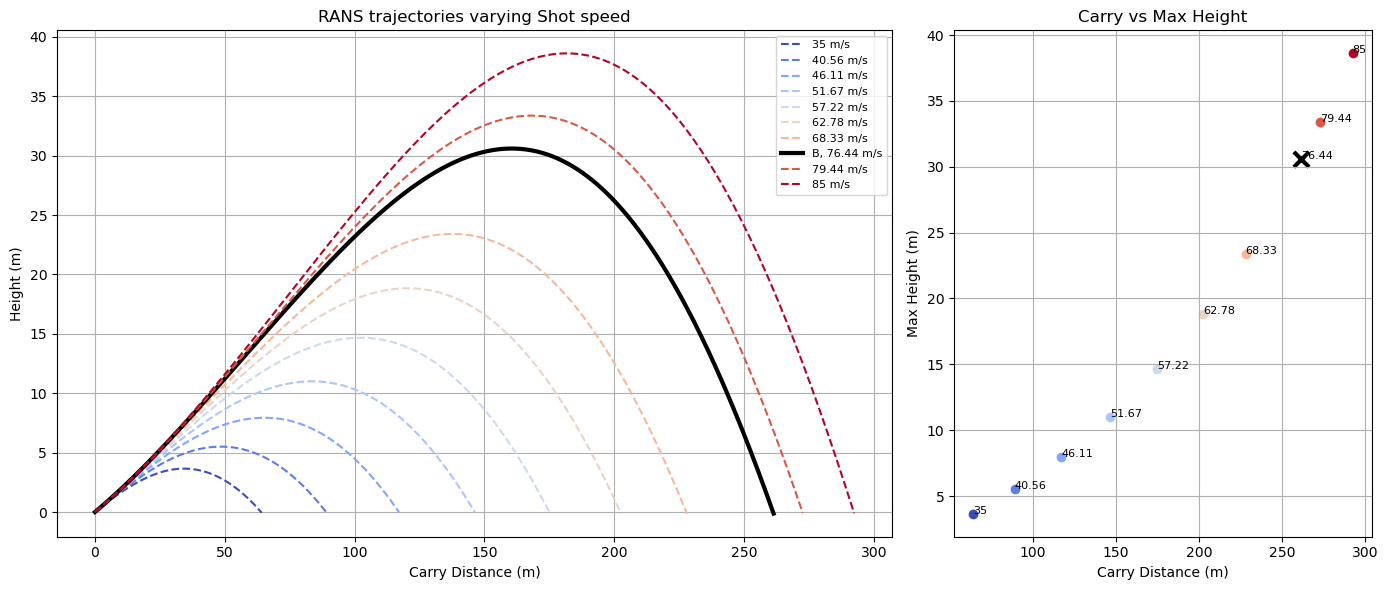

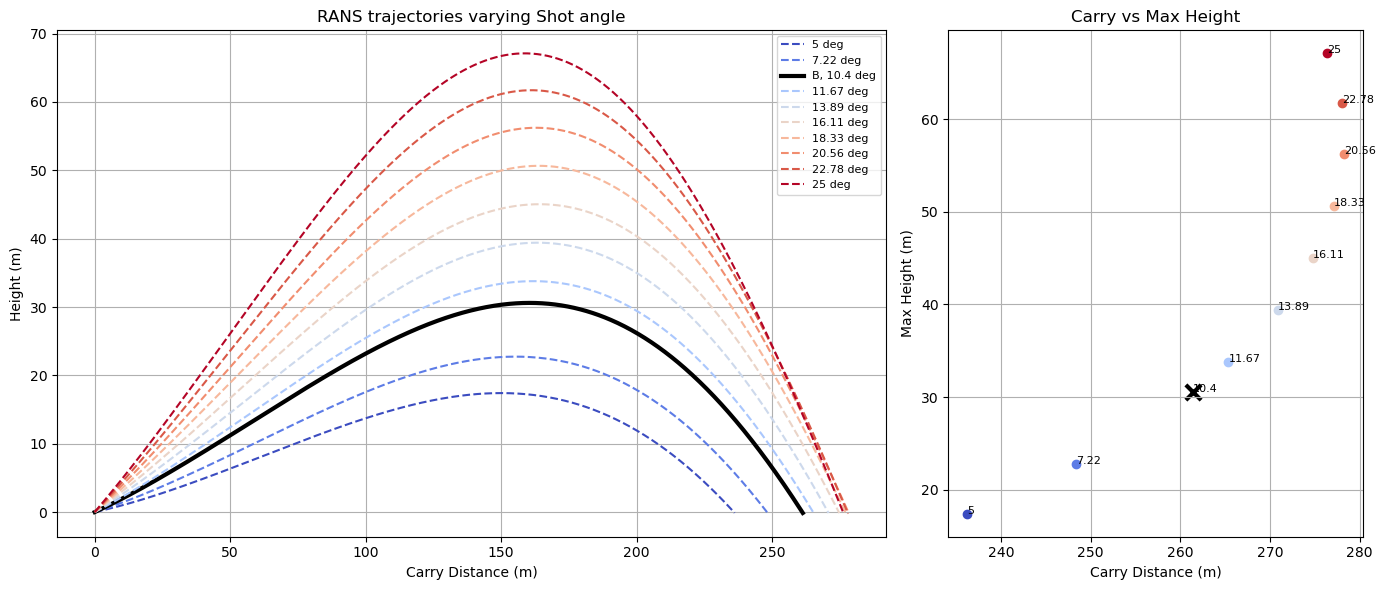

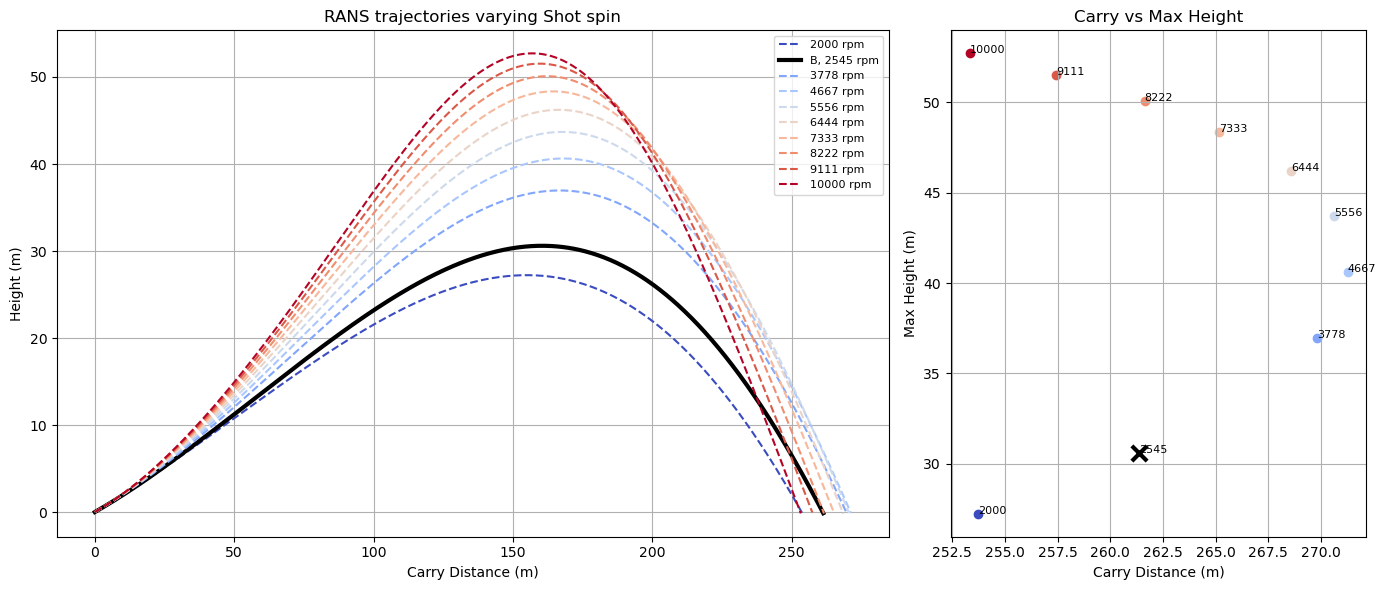

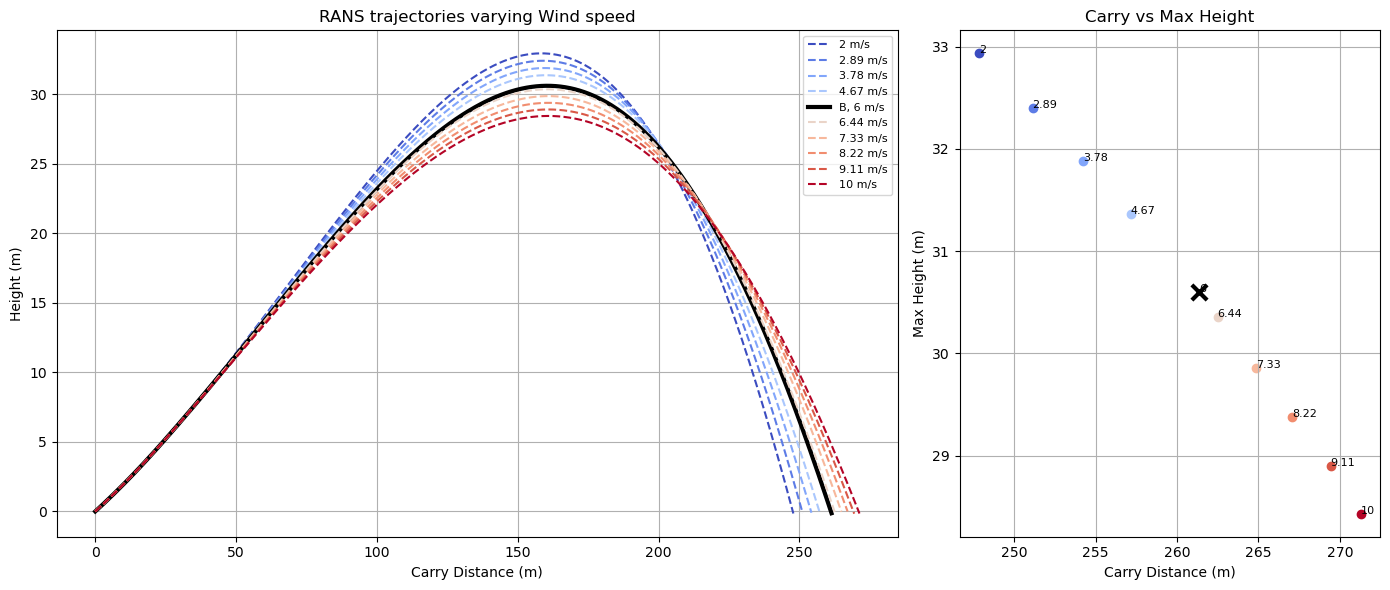

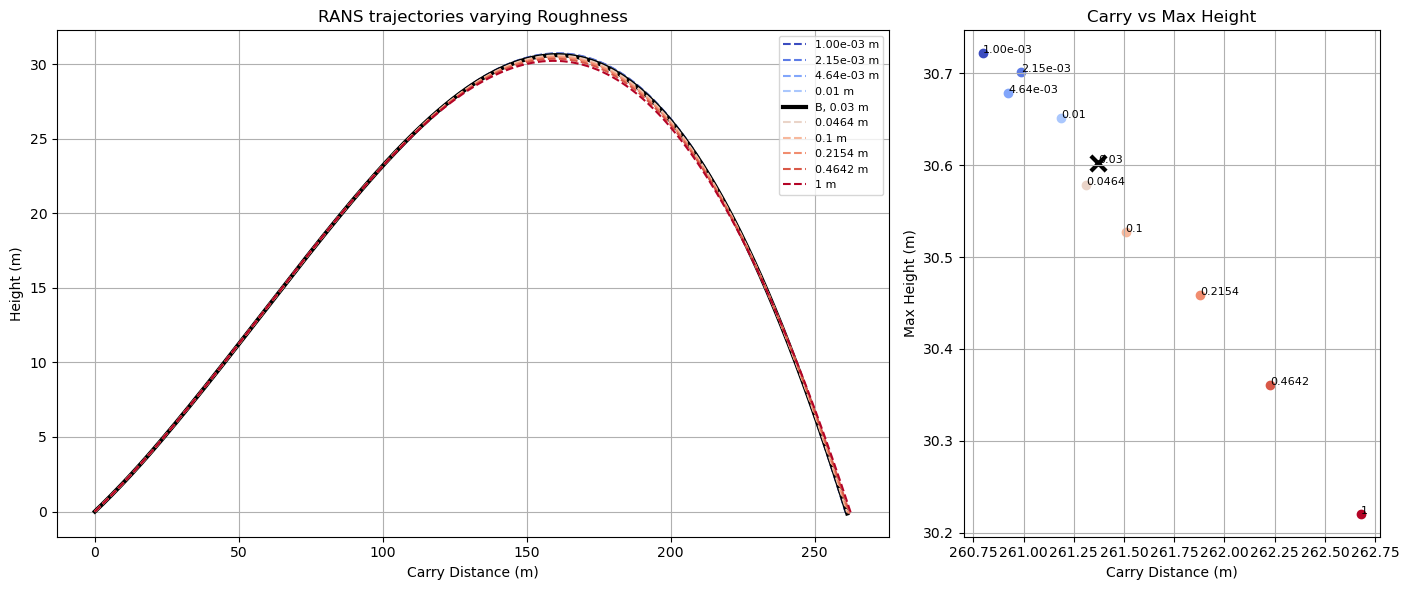

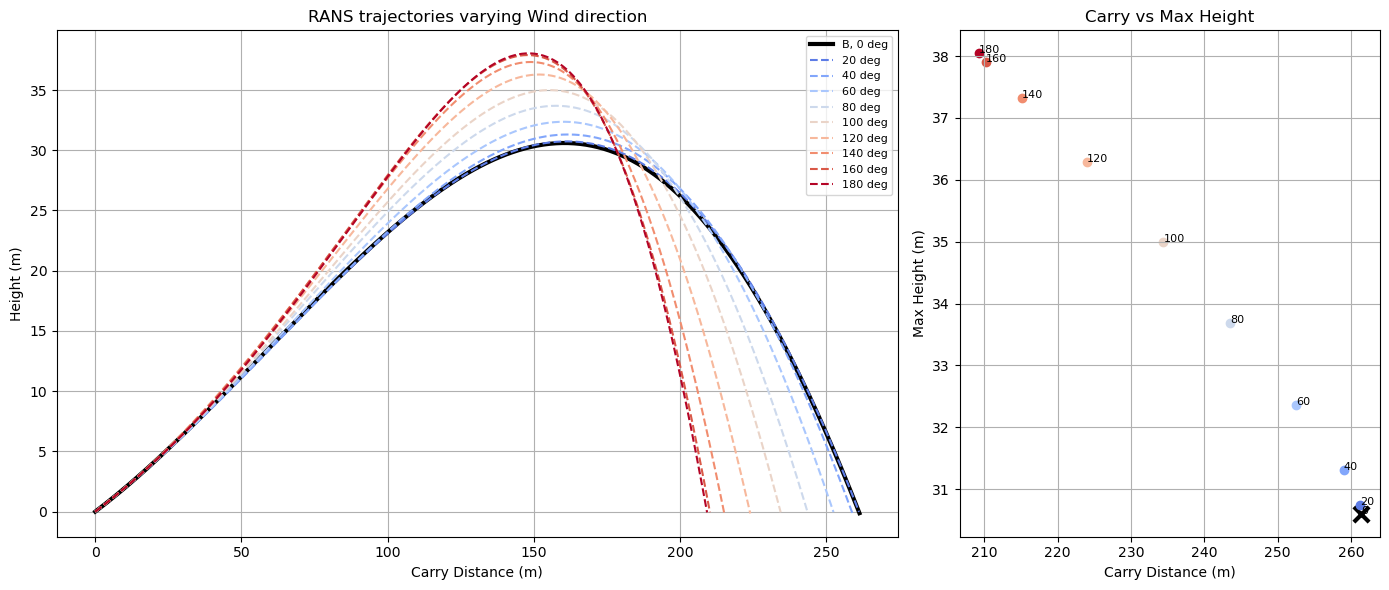

In [20]:
single_param_maxheight_carry('shot_speed',ref='rans')
single_param_maxheight_carry('shot_angle',ref='rans')
single_param_maxheight_carry('shot_spin',ref='rans')
single_param_maxheight_carry('U_ref',ref='rans')
single_param_maxheight_carry('z0',ref='rans')
single_param_maxheight_carry('direction',ref='rans')

## Single parameter variations

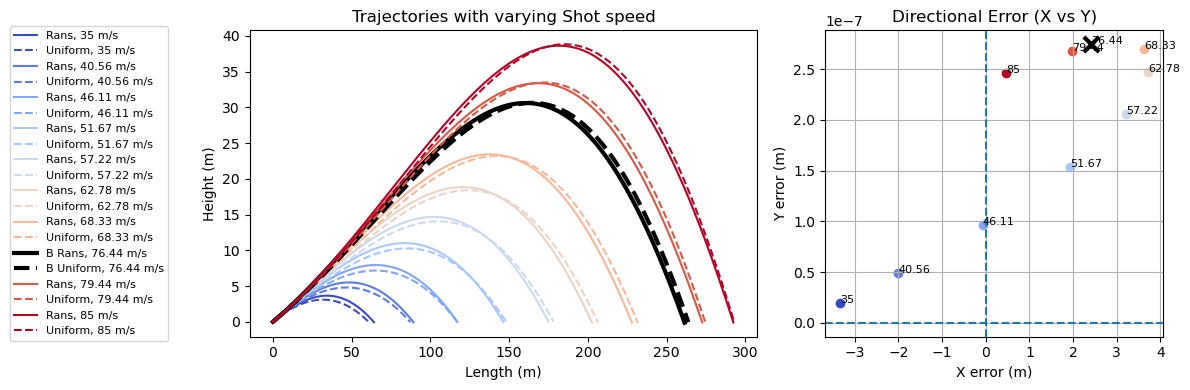

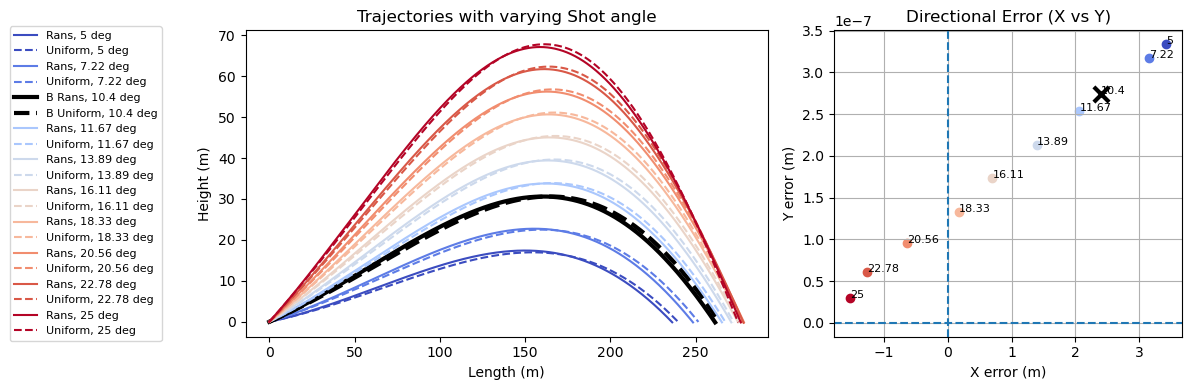

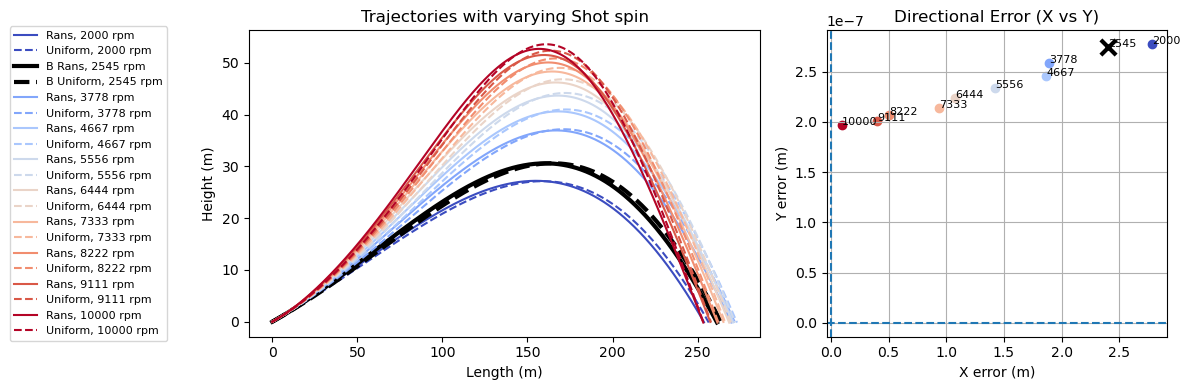

In [21]:
# Varying shot parameters
varying_parameter("shot_speed", test='uniform', ref='rans')
varying_parameter("shot_angle", test='uniform', ref='rans')
varying_parameter("shot_spin", test='uniform', ref='rans')

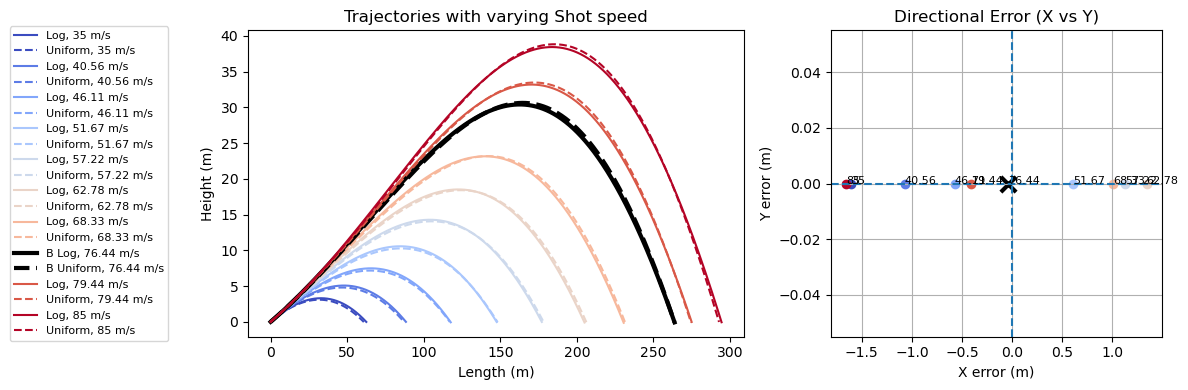

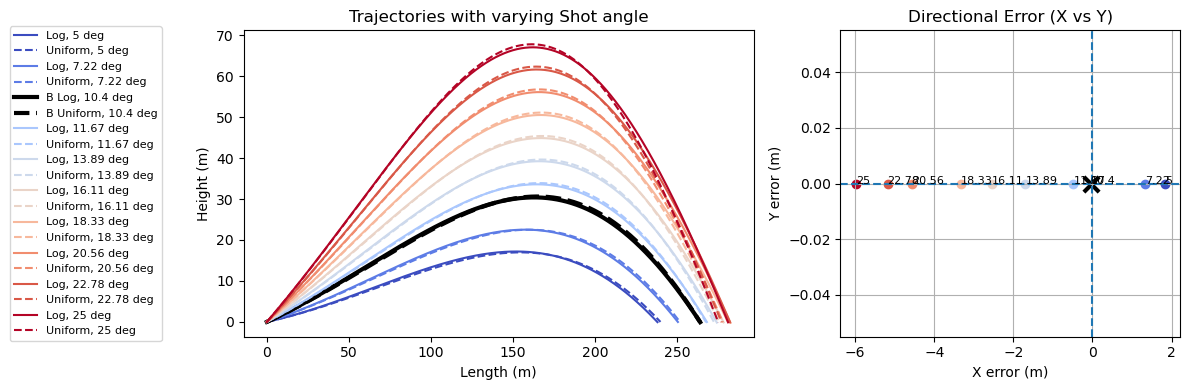

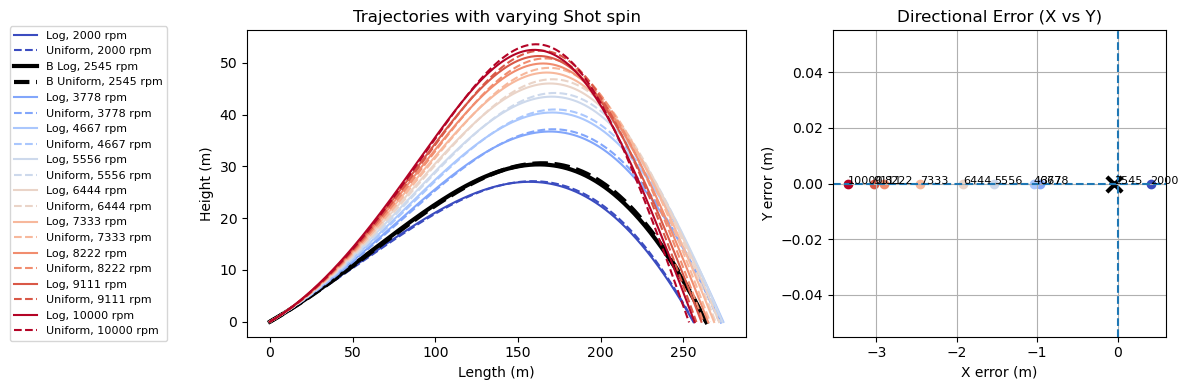

In [24]:
# Varying shot parameters LOG VS UNIFORM
varying_parameter("shot_speed", test='uniform', ref='log')
varying_parameter("shot_angle", test='uniform', ref='log')
varying_parameter("shot_spin", test='uniform', ref='log')

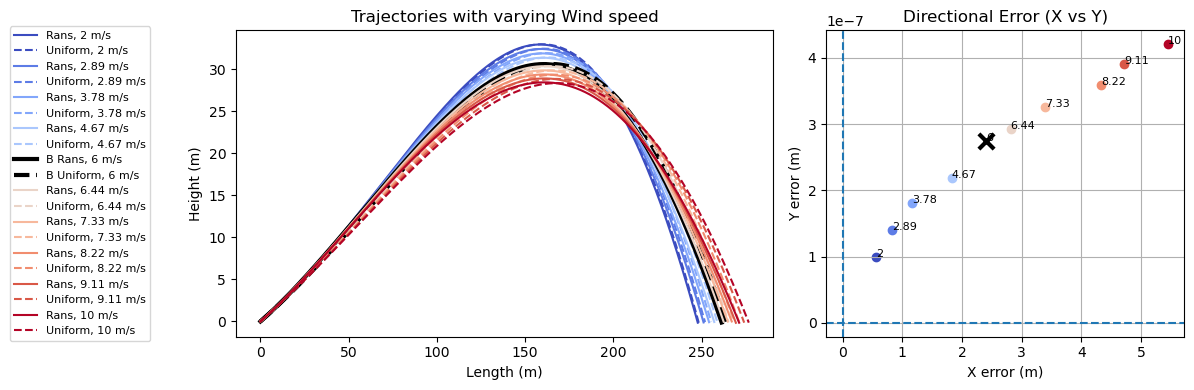

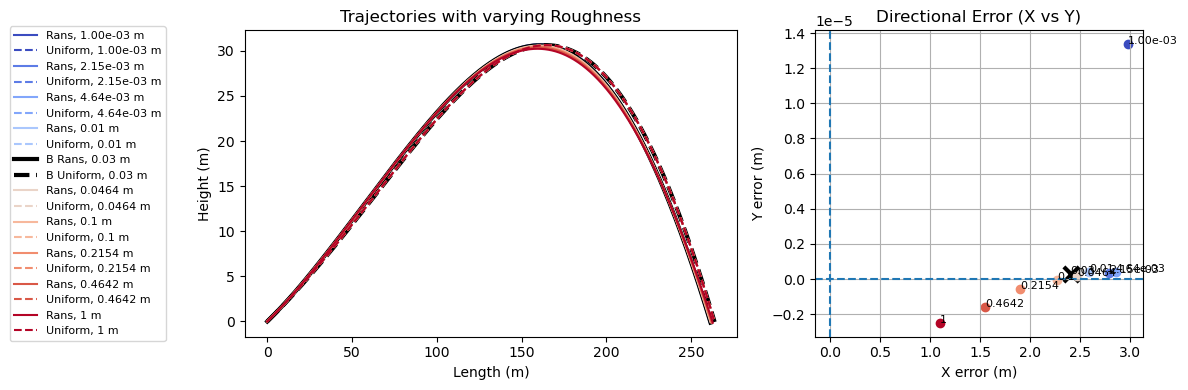

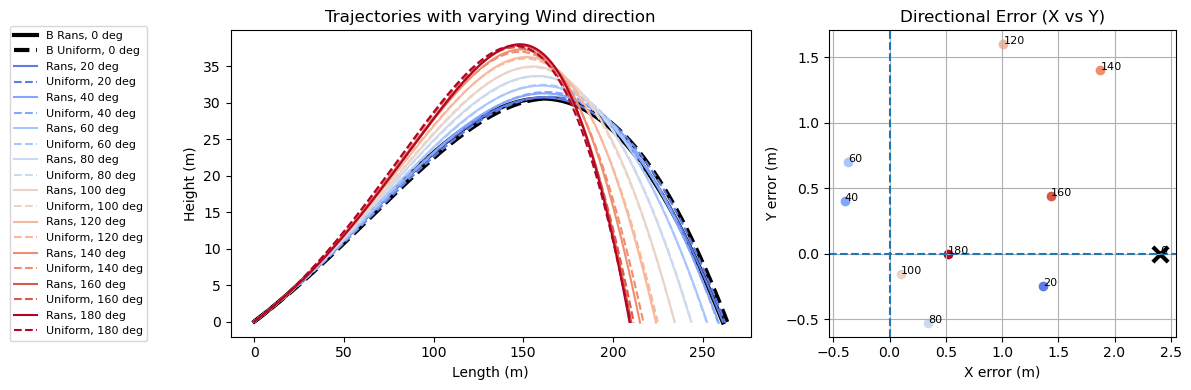

In [22]:
# Varying env parameters
varying_parameter("U_ref", test='uniform', ref='rans')
varying_parameter("z0", test='uniform', ref='rans')
varying_parameter("direction", test='uniform', ref='rans')

## Multiple parameter variations

In [23]:
# Cross parameter variations
varying_two_parameters_v2("shot_speed", "shot_angle", test='uniform', ref='rans')
varying_two_parameters_v2("shot_speed", "shot_spin", test='uniform', ref='rans')
varying_two_parameters_v2("shot_speed", "U_ref", test='uniform', ref='rans')
varying_two_parameters_v2("shot_speed", "z0", test='uniform', ref='rans')
varying_two_parameters_v2("shot_speed", "direction", test='uniform', ref='rans')
varying_two_parameters_v2("shot_angle", "shot_spin", test='uniform', ref='rans')
varying_two_parameters_v2("shot_angle", "U_ref", test='uniform', ref='rans')
varying_two_parameters_v2("shot_angle", "z0", test='uniform', ref='rans')
varying_two_parameters_v2("shot_angle", "direction", test='uniform', ref='rans')
varying_two_parameters_v2("shot_spin", "U_ref", test='uniform', ref='rans')
varying_two_parameters_v2("shot_spin", "z0", test='uniform', ref='rans')
varying_two_parameters_v2("shot_spin", "direction", test='uniform', ref='rans')
varying_two_parameters_v2("U_ref", "z0", test='uniform', ref='rans')
varying_two_parameters_v2("U_ref", "direction", test='uniform', ref='rans')
varying_two_parameters_v2("z0", "direction", test='uniform', ref='rans')

KeyboardInterrupt: 

## Double checking varying parameters

### Varying parameter log as test, rans as reference

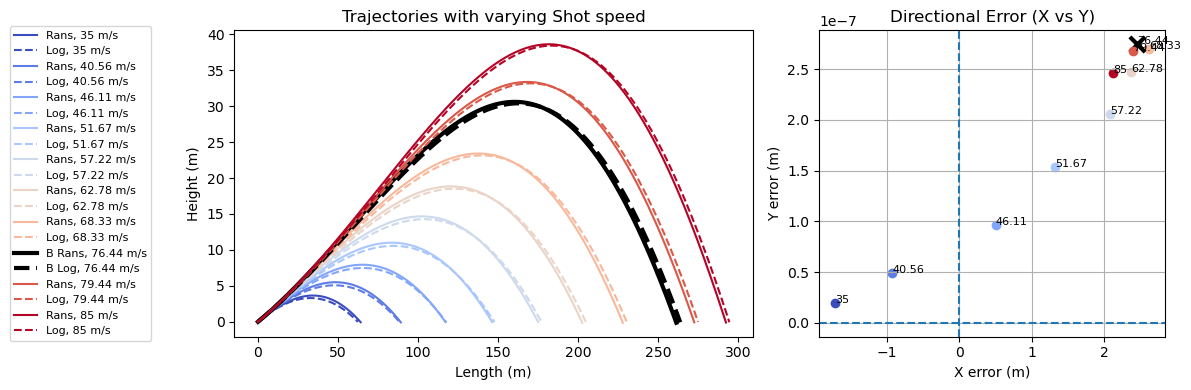

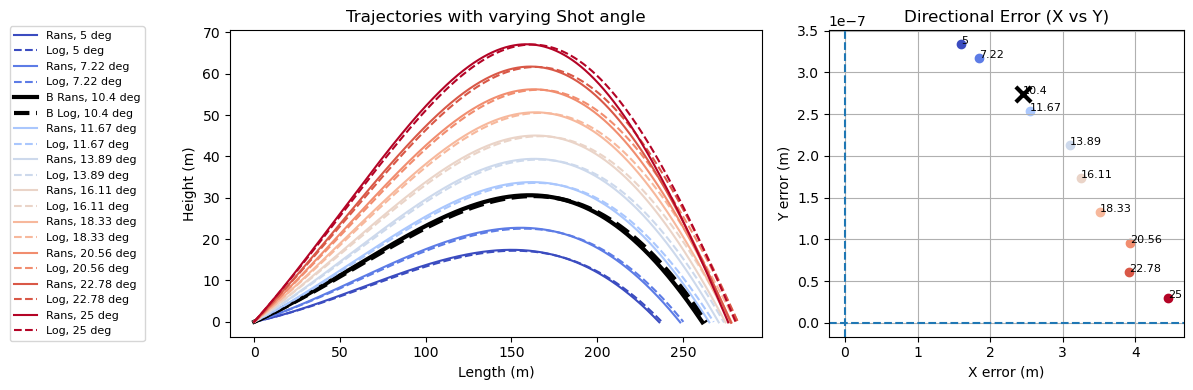

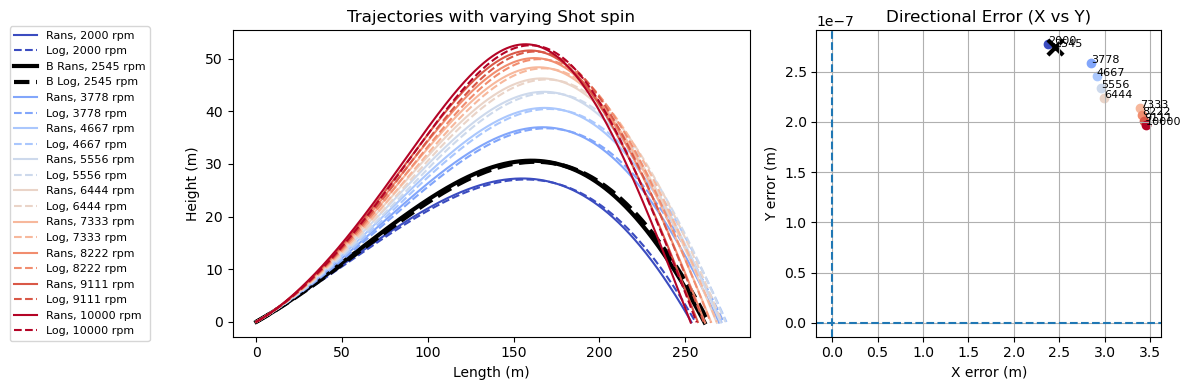

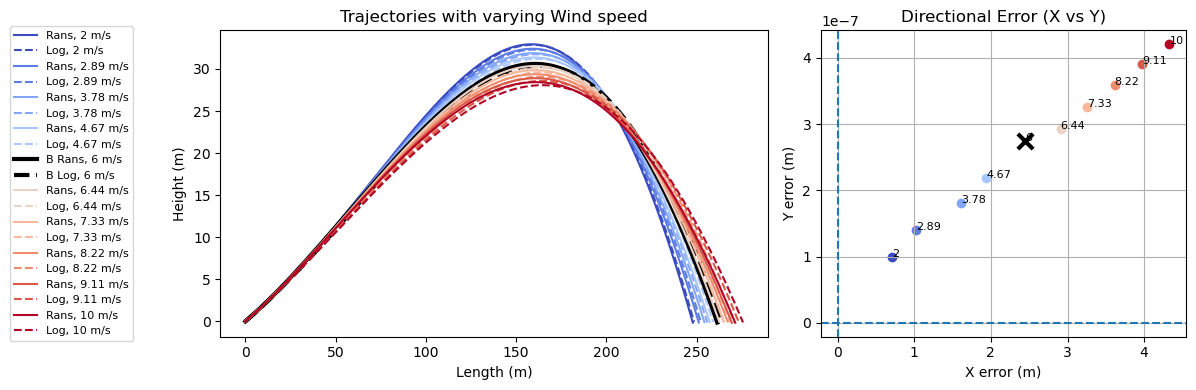

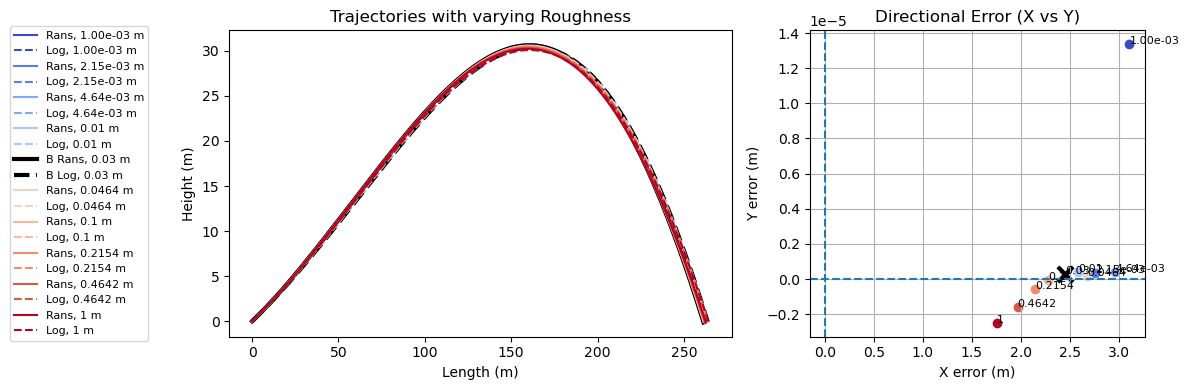

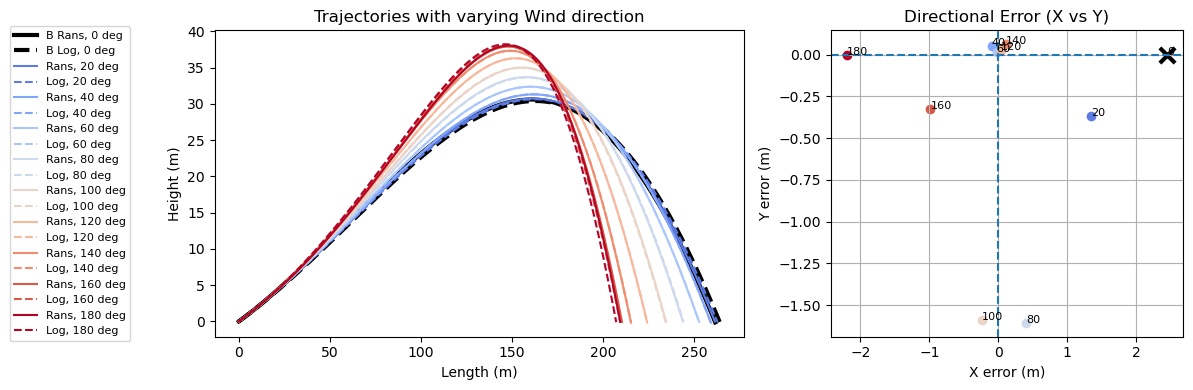

In [ ]:
varying_parameter("shot_speed", test='log', ref='rans')
varying_parameter("shot_angle", test='log', ref='rans')
varying_parameter("shot_spin", test='log', ref='rans')
varying_parameter("U_ref", test='log', ref='rans')
varying_parameter("z0", test='log', ref='rans')
varying_parameter("direction", test='log', ref='rans')

### Varying paramete uniform as test, log as reference

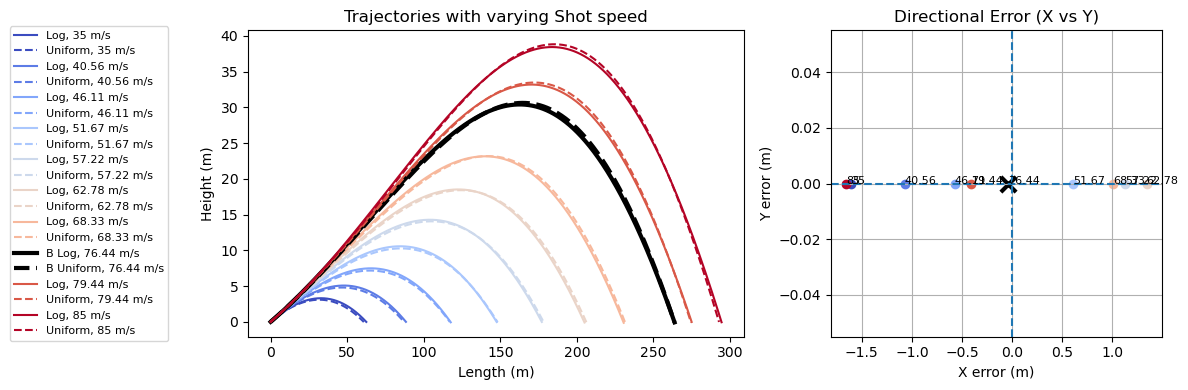

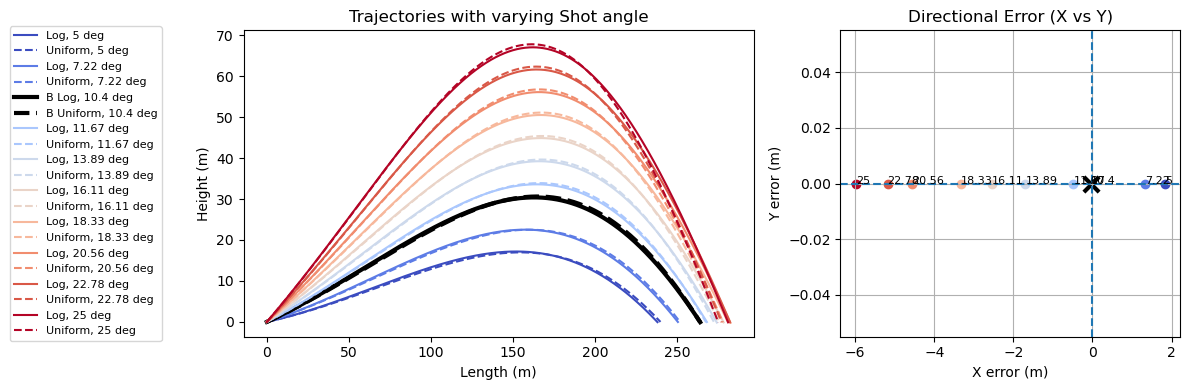

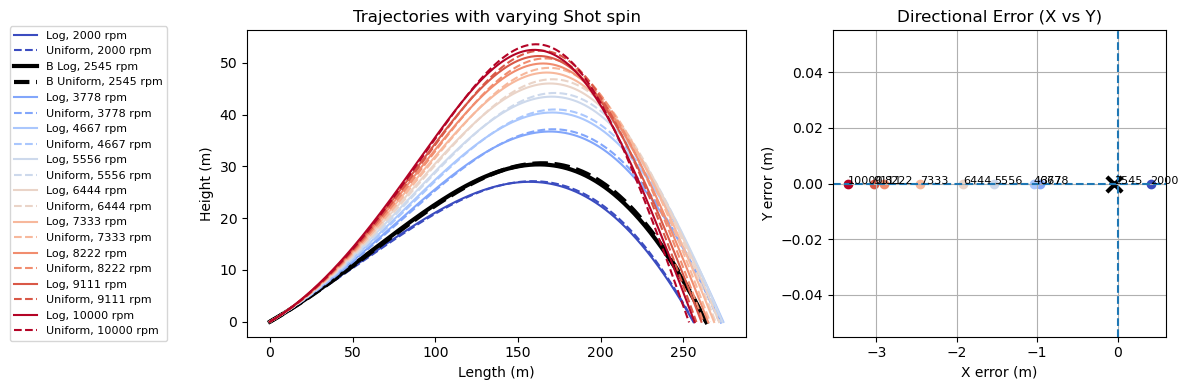

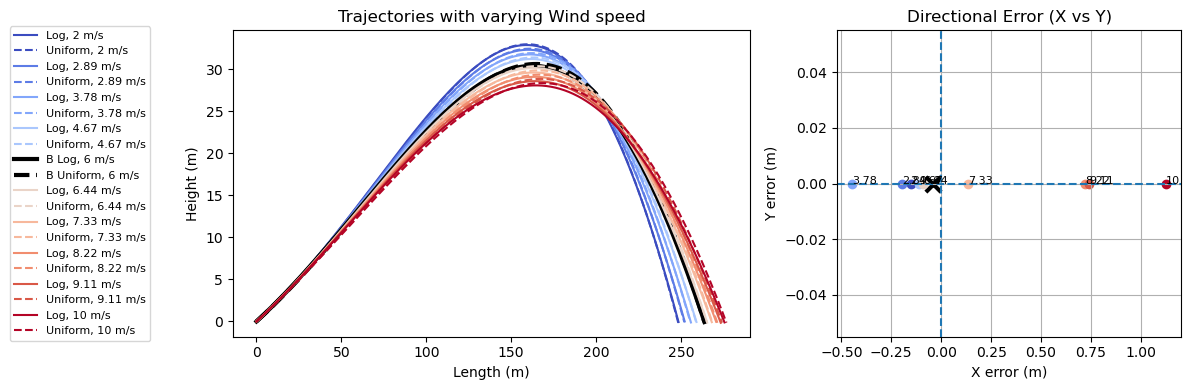

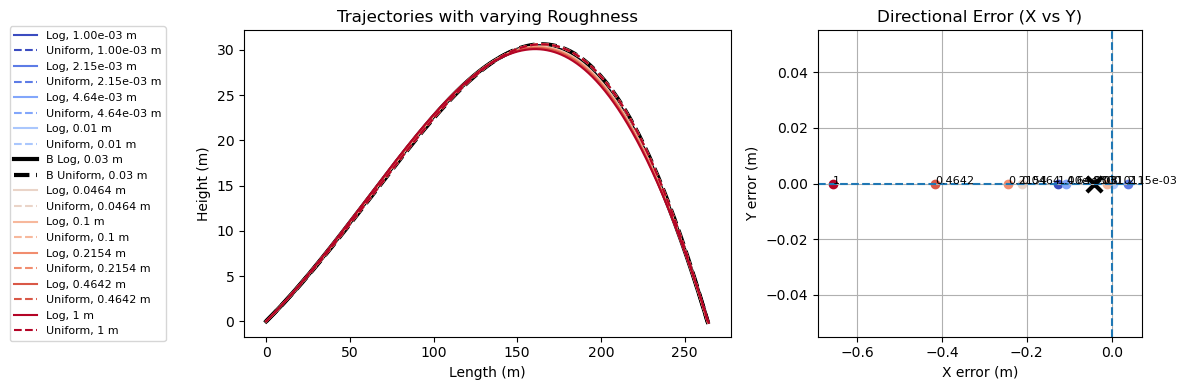

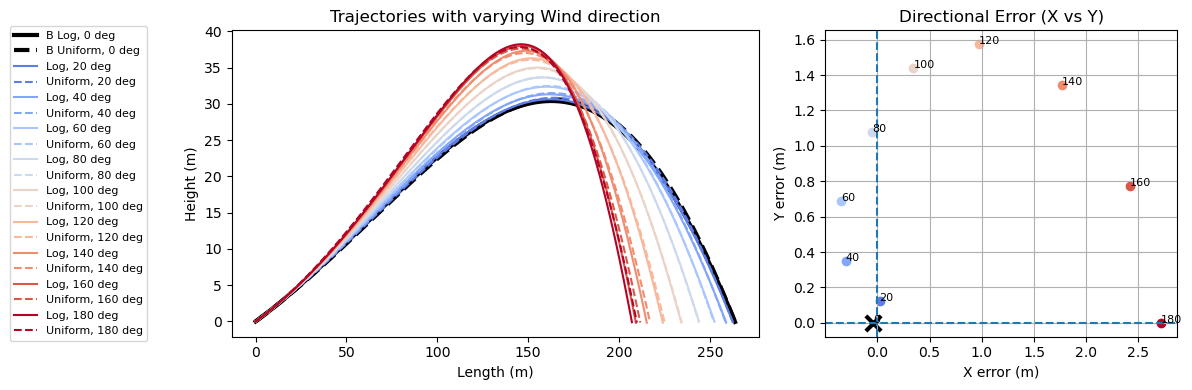

In [ ]:
varying_parameter("shot_speed", test='uniform', ref='log')
varying_parameter("shot_angle", test='uniform', ref='log')
varying_parameter("shot_spin", test='uniform', ref='log')
varying_parameter("U_ref", test='uniform', ref='log')
varying_parameter("z0", test='uniform', ref='log')
varying_parameter("direction", test='uniform', ref='log')

### Varying parameter, uniform as test, rans as reference

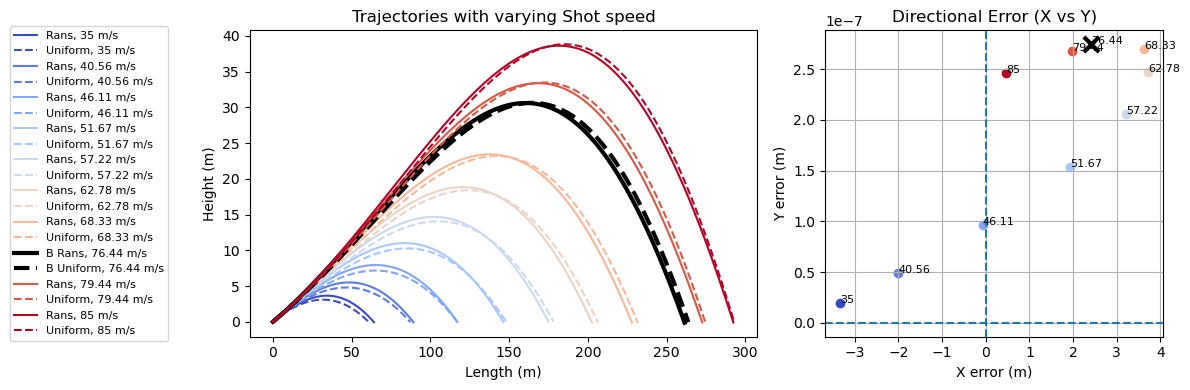

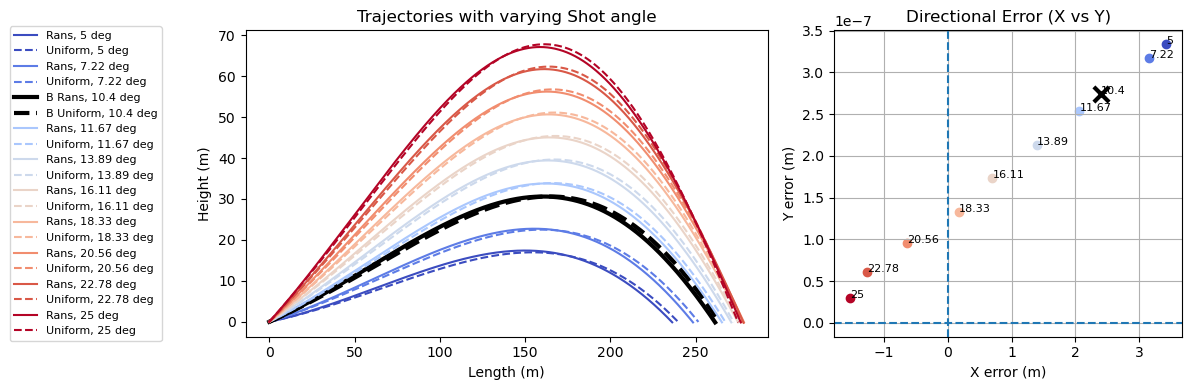

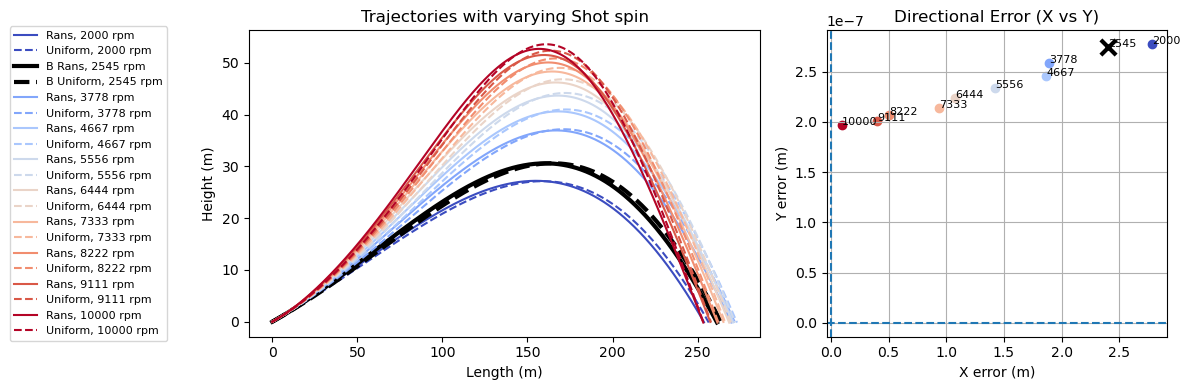

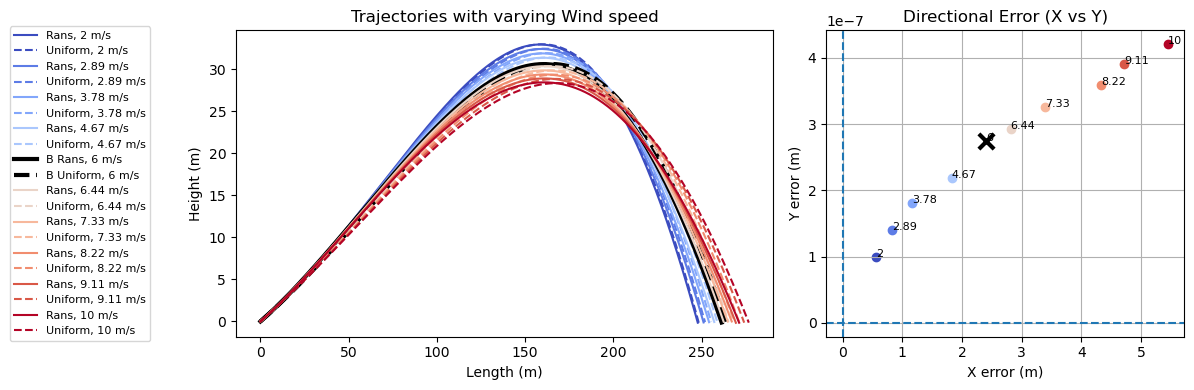

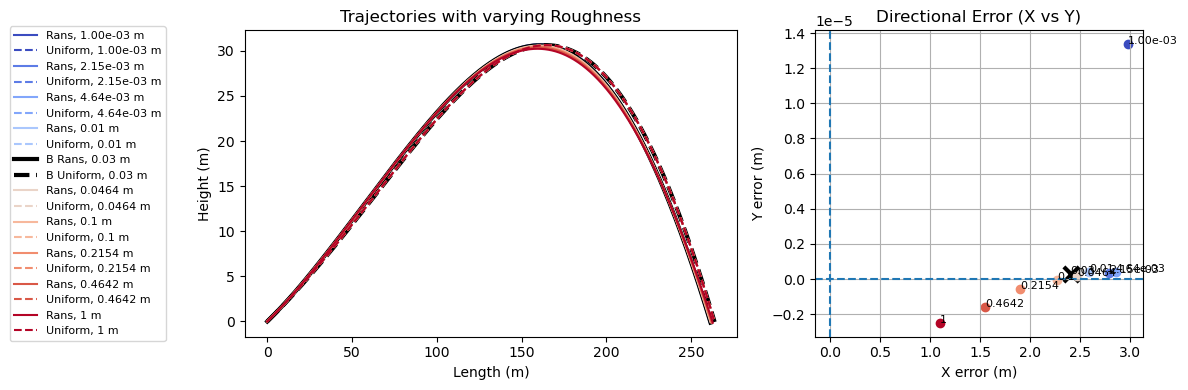

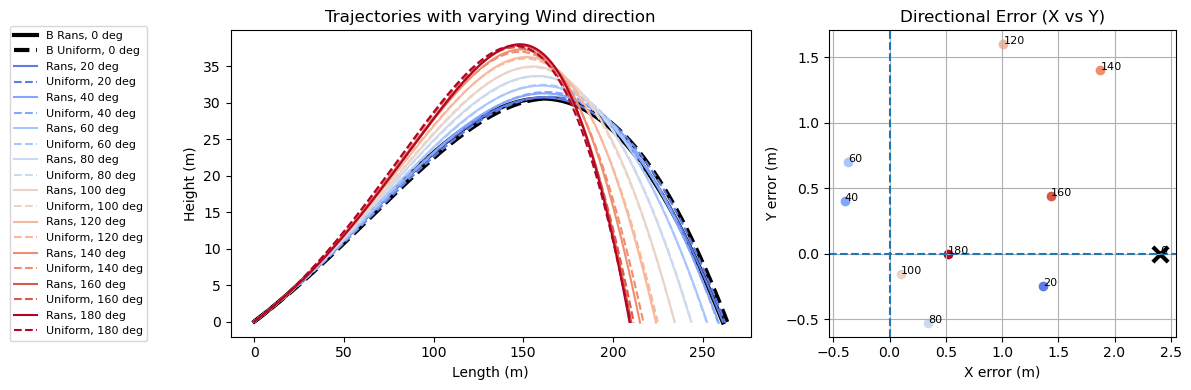

In [ ]:
varying_parameter("shot_speed", test='uniform', ref='rans')
varying_parameter("shot_angle", test='uniform', ref='rans')
varying_parameter("shot_spin", test='uniform', ref='rans')
varying_parameter("U_ref", test='uniform', ref='rans')
varying_parameter("z0", test='uniform', ref='rans')
varying_parameter("direction", test='uniform', ref='rans')

## Cross param variations showing max height, carry, landing position

In [ ]:
# Comparison script

# play field parameters - these make up the baseline shot
P0=np.array([0, 0, 0])
nx = 500        # length of play field
ny = 200        # width of play field
nz = 100        # height of play field
dt = 0.01       # time step

# Basis shot parameters - if not otherwise specified, these are used
shot_speed = 76.44384   # intital velocity
shot_angle = 10.4       # initial angle for trajectory	
shot_spin = 2545        # initial spin
spin_axis = 0           # spin axis adding impurity to the spin
orientation = 0         # play direction

# Basis wind parameters - if not otherwise specified, these are used
U_ref = 6      # reference wind speed at 10 meters above ground (6 m/s is approx. danish average)
z0 = 0.03       # surface roughness
direction = 0   # wind direction (0 is tailwind, 180 is headwind)

# script parameters
design_n = 10           # design parameter for # of values in design library
r = 150                 # Approximate radius of playfield, used for rotation and movement of player position

# filepaths for RANS simulations with varying z0
datafile01 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.001_mb_cartesian.nc'
datafile02 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.0021_mb_cartesian.nc'
datafile03 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.0046_mb_cartesian.nc'
datafile04 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.01_mb_cartesian.nc'
datafile05 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.03_mb_cartesian.nc'
datafile06 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.046_mb_cartesian.nc'
datafile07 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.1_mb_cartesian.nc'
datafile08 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.21_mb_cartesian.nc'
datafile09 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.46_mb_cartesian.nc'
datafile10 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_1_mb_cartesian.nc'

z0_file_library = {
    0.001:                  datafile01,
    0.0021544:              datafile02,
    0.0046415:              datafile03,
    0.01:                   datafile04,
    0.03:                   datafile05,
    0.046415:               datafile06, 
    0.1:                    datafile07,
    0.215443:               datafile08,
    0.464158:               datafile09,
    1.0:                    datafile10
}

def get_rans_file(z0_value):
    keys = np.array(list(z0_file_library.keys()))
    nearest = keys[np.argmin(np.abs(keys - z0_value))]
    return z0_file_library[nearest]

basefile = get_rans_file(z0)

# baseline values
baseline_values = {
    "shot_speed": shot_speed,
    "shot_angle": shot_angle,
    "shot_spin": shot_spin,
    "U_ref": U_ref,
    "z0": z0,
    "direction": direction,
    "file":basefile,
}

def include_baseline(values, baseline):
    """
    Ensures baseline is included while keeping exactly n_total samples.
    Replaces the nearest sampled value if baseline is not already present.
    """
    values = np.array(values)
    # if baseline already exists, just return sorted values
    if np.isclose(values, baseline).any():
        return np.sort(values)
    # find nearest existing point and replace it
    idx = np.argmin(np.abs(values - baseline))
    values[idx] = baseline
    return np.sort(values)

# parameter library
parameter_library = {
    "shot_speed": {
        "values": include_baseline(np.linspace(35, 85, design_n), shot_speed),
        "name": "Shot speed",
        "unit": "m/s"
    },
    "shot_angle": {
        "values": include_baseline(np.linspace(5, 25, design_n), shot_angle),
        "name": "Shot angle",
        "unit": "deg"
    },
    "shot_spin": {
        "values": include_baseline(np.linspace(2000, 10000, design_n), shot_spin),
        "name": "Shot spin",
        "unit": "rpm"
    },
    "U_ref": {
        "values": include_baseline(np.linspace(2, 10, design_n), U_ref),
        "name": "Wind speed",
        "unit": "m/s"
    },
    "z0": {
        "values": include_baseline(np.logspace(np.log10(0.001), np.log10(1), design_n), z0),
        "name": "Roughness",
        "unit": "m"
    },
    "direction": {
        "values": include_baseline(np.array([0,315,270]), direction),
        "name": "Wind direction",
        "unit": "deg"
    }
}

# --- player positions ----
new_P0 = np.array([0, 0, 0])    # blank position array
rotation_configs = []
for ang in parameter_library['direction']['values']:
    theta = ang * (np.pi/180.0)
    x = -np.cos(theta) * r
    y = -np.sin(theta) * r
    rotation_configs.append({"direction": ang,"orientation": ang,"P0": np.array([x, y, 0])})

# --- plot nice
def get_rotated_geometry(direction, r=r):
    theta = direction * (np.pi/180.0)

    x = -np.cos(theta) * r
    y = -np.sin(theta) * r
    P0_new = np.array([x, y, 0])

    orientation_new = direction   # may become direction+180 depending on convention

    return P0_new, orientation_new

def transform_to_local_frame(p, direction):
    P0_used, _ = get_rotated_geometry(direction)

    theta = direction * (np.pi/180.0)

    # translate
    xt = p[:, 0] - P0_used[0]
    yt = p[:, 1] - P0_used[1]

    # rotate into shot-aligned frame
    x_local = xt * np.cos(theta) + yt * np.sin(theta)
    y_local = -xt * np.sin(theta) + yt * np.cos(theta)

    z_local = p[:, 2]

    return np.column_stack((x_local, y_local, z_local))

def is_baseline(param_key, value, tol=1e-8):
    return np.isclose(value, baseline_values[param_key], atol=tol)

def format_param(v):
    if v == 0:
        return "0"
    elif abs(v) < 1e-2:
        return f"{v:.2e}"
    elif abs(v) >= 1000:
        return f"{v:.0f}"
    elif abs(v) >= 1:
        return f"{v:.2f}".rstrip('0').rstrip('.')
    else:
        return f"{v:.4f}".rstrip('0').rstrip('.')

# --- Error Models ---
def percent_distance_error(ref_p, test_p):
    dx = test_p[-1, 0] - ref_p[-1, 0]
    dy = test_p[-1, 1] - ref_p[-1, 1]
    norm = np.sqrt((ref_p[-1, 0]-ref_p[0, 0])**2 + (ref_p[-1, 1]-ref_p[0, 1])**2)
    return np.sqrt(dx**2 + dy**2) / norm * 100

def distance_error(ref_p, test_p):
    dx = test_p[-1, 0] - ref_p[-1, 0]
    dy = test_p[-1, 1] - ref_p[-1, 1]
    return np.sqrt(dx**2 + dy**2)

def x_distance_error(ref_p, test_p):
    return test_p[-1, 0] - ref_p[-1, 0]

def y_distance_error(ref_p, test_p):
    return test_p[-1, 1] - ref_p[-1, 1]

def build_wind(profile, U_ref, z0, rans_file=None):
    if profile == 'uniform':
        return WindField(profile='uniform', U_ref=U_ref)

    elif profile == 'log':
        return WindField(profile='log', U_ref=U_ref, z0=z0)

    elif profile == 'rans':
        return WindField(profile='rans', ds=rans_file, U_ref=U_ref)

    else:
        raise ValueError(f"Unknown profile: {profile}")
    
def solve_profile(profile, shot_speed, shot_angle, shot_spin,
                  U_ref, z0, direction, orientation_used, P0_used, rans_file):

    wind = build_wind(profile, U_ref, z0, rans_file)

    traj = Trajectory(
        ball_speed=shot_speed,
        launch_angle=shot_angle,
        spin_rate=shot_spin,
        spin_axis=spin_axis,
        wind=wind,
        orientation=orientation_used,
        P0=P0_used
    )

    traj.solve(solver='euler', dt=dt)
    return traj.p

def run_simulation(shot_speed=shot_speed, shot_angle=shot_angle,
                   shot_spin=shot_spin, U_ref=U_ref,
                   z0=z0, direction=direction,
                   test='uniform', ref='rans'):

    # coupled geometry from direction
    P0_used, orientation_used = get_rotated_geometry(direction)

    # coupled RANS dataset from z0
    rans_file = get_rans_file(z0)

    # only solve the two requested profiles
    ref_p = solve_profile(ref, shot_speed, shot_angle, shot_spin,
                          U_ref, z0, direction,
                          orientation_used, P0_used, rans_file)

    test_p = solve_profile(test, shot_speed, shot_angle, shot_spin,
                           U_ref, z0, direction,
                           orientation_used, P0_used, rans_file)

    return ref_p, test_p

In [ ]:
def varying_two_parameters_v3(
    param1_key,
    param2_key,
    shot_speed=shot_speed,
    shot_angle=shot_angle,
    shot_spin=shot_spin,
    U_ref=U_ref,
    z0=z0,
    direction=direction,
    ref='rans'
):

    p1 = parameter_library[param1_key]
    p2 = parameter_library[param2_key]

    param1 = p1["values"]
    param2 = p2["values"]

    # -------------------------------------------------
    # Storage
    # -------------------------------------------------
    max_height = np.zeros((len(param1), len(param2)))
    carry = np.zeros((len(param1), len(param2)))

    x_land = np.zeros((len(param1), len(param2)))
    y_land = np.zeros((len(param1), len(param2)))

    # -------------------------------------------------
    # Run simulations
    # -------------------------------------------------
    for i, val1 in enumerate(param1):

        for j, val2 in enumerate(param2):

            kwargs = dict(
                shot_speed=shot_speed,
                shot_angle=shot_angle,
                shot_spin=shot_spin,
                U_ref=U_ref,
                z0=z0,
                direction=direction
            )

            kwargs[param1_key] = val1
            kwargs[param2_key] = val2

            # Run RANS simulation
            ref_p, _ = run_simulation(
                **kwargs,
                test='rans',
                ref='rans'
            )

            # Handle varying direction exactly like
            # varying_parameter()
            transform_angle = (
                val1 if param1_key == "direction"
                else val2 if param2_key == "direction"
                else direction
            )

            traj = transform_to_local_frame(
                ref_p,
                transform_angle
            )

            # Local coordinates
            x = traj[:, 0]   # along-trajectory distance
            y = traj[:, 1]   # transverse carry
            z = traj[:, 2]   # height

            # Metrics
            max_height[i, j] = np.max(z)

            carry[i, j] = x[-1]

            x_land[i, j] = x[-1]
            y_land[i, j] = y[-1]

    # -------------------------------------------------
    # Baseline indices
    # -------------------------------------------------
    i_base = np.where(
        np.isclose(param1, baseline_values[param1_key])
    )[0][0]

    j_base = np.where(
        np.isclose(param2, baseline_values[param2_key])
    )[0][0]

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 6)
    )

    ax1, ax2 = axes

    colors = plt.cm.coolwarm(
        np.linspace(0, 1, len(param1))
    )

    # =================================================
    # Max height vs carry
    # =================================================
    for i, val1 in enumerate(param1):

        label = f"{format_param(val1)} {p1['unit']}"

        ax1.scatter(
            carry[i, :],
            max_height[i, :],
            marker='o',
            color=colors[i],
            label=label
        )

    ax1.scatter(
        carry[i_base, j_base],
        max_height[i_base, j_base],
        color='black',
        marker='x',
        s=150,
        linewidths=3,
        zorder=5,
        label='Baseline'
    )

    ax1.set_xlabel("Carry Distance (m)")
    ax1.set_ylabel("Maximum Height (m)")
    ax1.set_title("Maximum Height vs Carry")
    ax1.grid()

    # =================================================
    # Landing position
    # =================================================
    for i, val1 in enumerate(param1):

        label = f"{format_param(val1)} {p1['unit']}"

        ax2.scatter(
            x_land[i, :],
            y_land[i, :],
            marker='o',
            color=colors[i],
            label=label
        )

        # optional parameter labels
        #for j in range(len(param2)):
        #    ax2.text(
        #        x_land[i, j],
        #        y_land[i, j],
        #        format_param(param2[j]),
        #        fontsize=8
        #    )

    ax2.scatter(
        x_land[i_base, j_base],
        y_land[i_base, j_base],
        color='black',
        marker='x',
        s=150,
        linewidths=3,
        zorder=5
    )

    ax2.set_xlabel("Landing X Position (m)")
    ax2.set_ylabel("Landing Y Position (m)")
    ax2.set_title("Landing Position")
    ax2.set_ylim(-1,27)
    ax2.grid()


    ax2.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9
    )

    plt.suptitle(
        f"{p1['name']} vs {p2['name']} (RANS)",
        fontsize=15
    )

    
    plt.tight_layout()
    plt.show()

In [ ]:
def varying_two_parameters_v3(
    param1_key,
    param2_key,
    shot_speed=shot_speed,
    shot_angle=shot_angle,
    shot_spin=shot_spin,
    U_ref=U_ref,
    z0=z0,
    direction=direction,
    ref='rans'
):

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    p1 = parameter_library[param1_key]
    p2 = parameter_library[param2_key]

    param1 = p1["values"]
    param2 = p2["values"]

    # -------------------------------------------------
    # Storage for plotting
    # -------------------------------------------------
    max_height = np.zeros((len(param1), len(param2)))
    carry = np.zeros((len(param1), len(param2)))
    x_land = np.zeros((len(param1), len(param2)))
    y_land = np.zeros((len(param1), len(param2)))

    # -------------------------------------------------
    # CSV storage
    # -------------------------------------------------
    results = []

    # -------------------------------------------------
    # Run simulations
    # -------------------------------------------------
    for i, val1 in enumerate(param1):

        for j, val2 in enumerate(param2):

            kwargs = dict(
                shot_speed=shot_speed,
                shot_angle=shot_angle,
                shot_spin=shot_spin,
                U_ref=U_ref,
                z0=z0,
                direction=direction
            )

            kwargs[param1_key] = val1
            kwargs[param2_key] = val2

            # Run RANS only
            ref_p, _ = run_simulation(
                **kwargs,
                test='rans',
                ref='rans'
            )

            # Direction handling (same logic as your working function)
            transform_angle = (
                val1 if param1_key == "direction"
                else val2 if param2_key == "direction"
                else direction
            )

            traj = transform_to_local_frame(
                ref_p,
                transform_angle
            )

            x = traj[:, 0]
            y = traj[:, 1]
            z = traj[:, 2]

            # -------------------------------------------------
            # Metrics
            # -------------------------------------------------
            max_h = np.max(z)
            carry_val = x[-1]
            land_x = x[-1]
            land_y = y[-1]

            max_height[i, j] = max_h
            carry[i, j] = carry_val
            x_land[i, j] = land_x
            y_land[i, j] = land_y

            # -------------------------------------------------
            # Save row for CSV
            # -------------------------------------------------
            results.append({
                param1_key: val1,
                param2_key: val2,
                "carry_m": carry_val,
                "max_height_m": max_h,
                "landing_x_m": land_x,
                "landing_y_m": land_y
            })

    # -------------------------------------------------
    # Baseline indices
    # -------------------------------------------------
    i_base = np.where(
        np.isclose(param1, baseline_values[param1_key])
    )[0][0]

    j_base = np.where(
        np.isclose(param2, baseline_values[param2_key])
    )[0][0]

    # -------------------------------------------------
    # Plot setup
    # -------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ax1, ax2 = axes

    colors = plt.cm.coolwarm(
        np.linspace(0, 1, len(param1))
    )

    # =================================================
    # Plot 1: Max height vs carry
    # =================================================
    for i, val1 in enumerate(param1):

        ax1.scatter(
            carry[i, :],
            max_height[i, :],
            color=colors[i],
            label=f"{format_param(val1)} {p1['unit']}"
        )

    ax1.scatter(
        carry[i_base, j_base],
        max_height[i_base, j_base],
        color='black',
        marker='x',
        s=150,
        linewidths=3,
        zorder=5,
        label='Baseline'
    )

    ax1.set_xlabel("Carry Distance (m)")
    ax1.set_ylabel("Maximum Height (m)")
    ax1.set_title("Maximum Height vs Carry")
    ax1.grid()

    # =================================================
    # Plot 2: Landing positions
    # =================================================
    for i, val1 in enumerate(param1):

        ax2.scatter(
            x_land[i, :],
            y_land[i, :],
            color=colors[i],
            label=f"{format_param(val1)} {p1['unit']}"
        )

    ax2.scatter(
        x_land[i_base, j_base],
        y_land[i_base, j_base],
        color='black',
        marker='x',
        s=150,
        linewidths=3,
        zorder=5
    )

    ax2.set_xlabel("Landing X Position (m)")
    ax2.set_ylabel("Landing Y Position (m)")
    ax2.set_title("Landing Position")
    ax2.set_ylim(-1, 27)
    ax2.grid()

    ax2.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9
    )

    plt.suptitle(
        f"{p1['name']} vs {p2['name']} (RANS)",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()

    # -------------------------------------------------
    # Save CSV
    # -------------------------------------------------
    df = pd.DataFrame(results)

    filename = f"rans_{param1_key}_vs_{param2_key}.csv"
    df.to_csv(filename, index=False)

    print(f"Saved results to: {filename}")

    return df

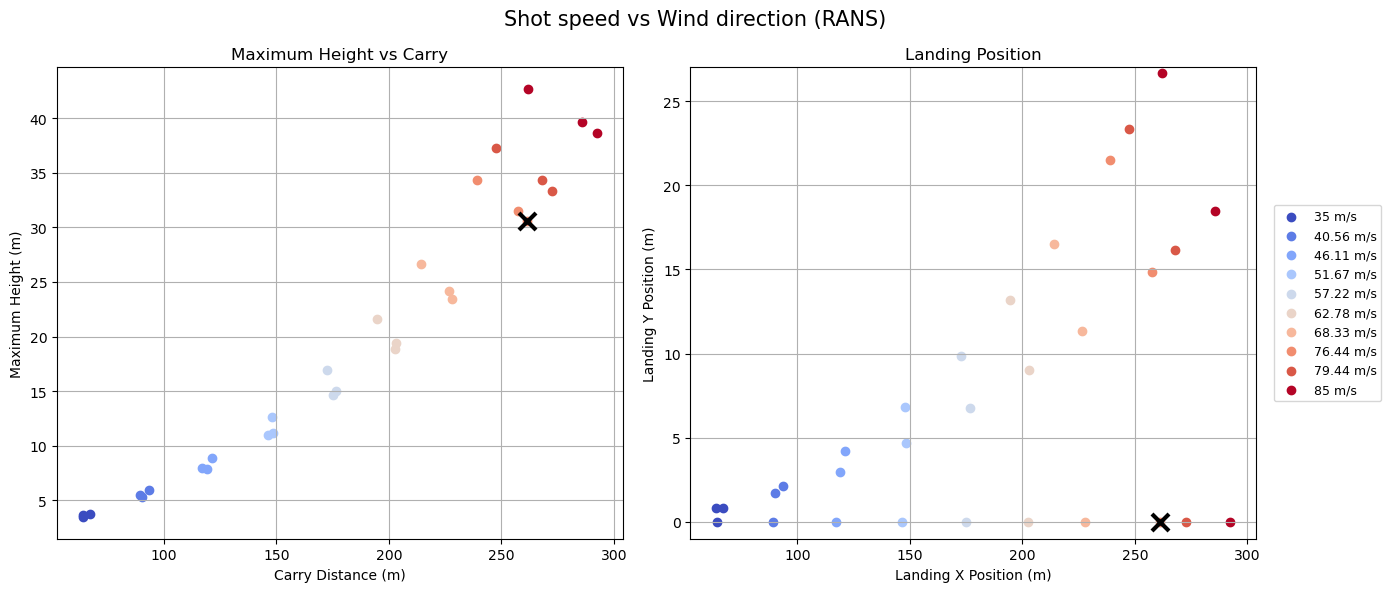

Saved results to: rans_shot_speed_vs_direction.csv


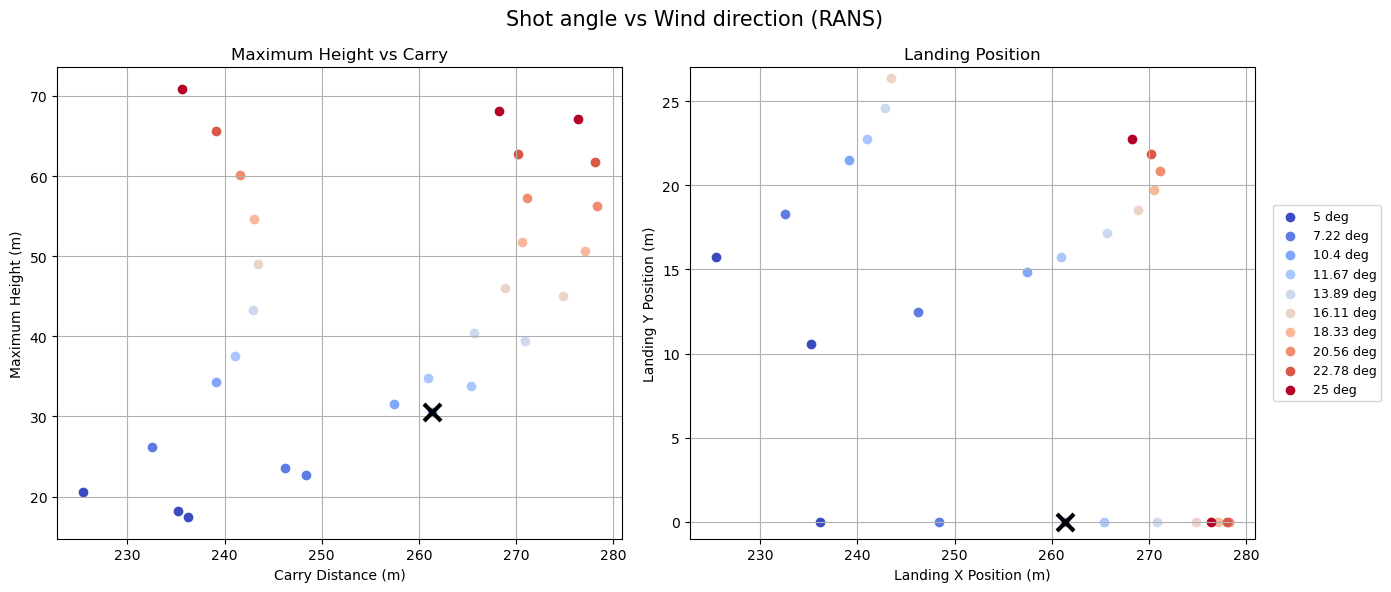

Saved results to: rans_shot_angle_vs_direction.csv


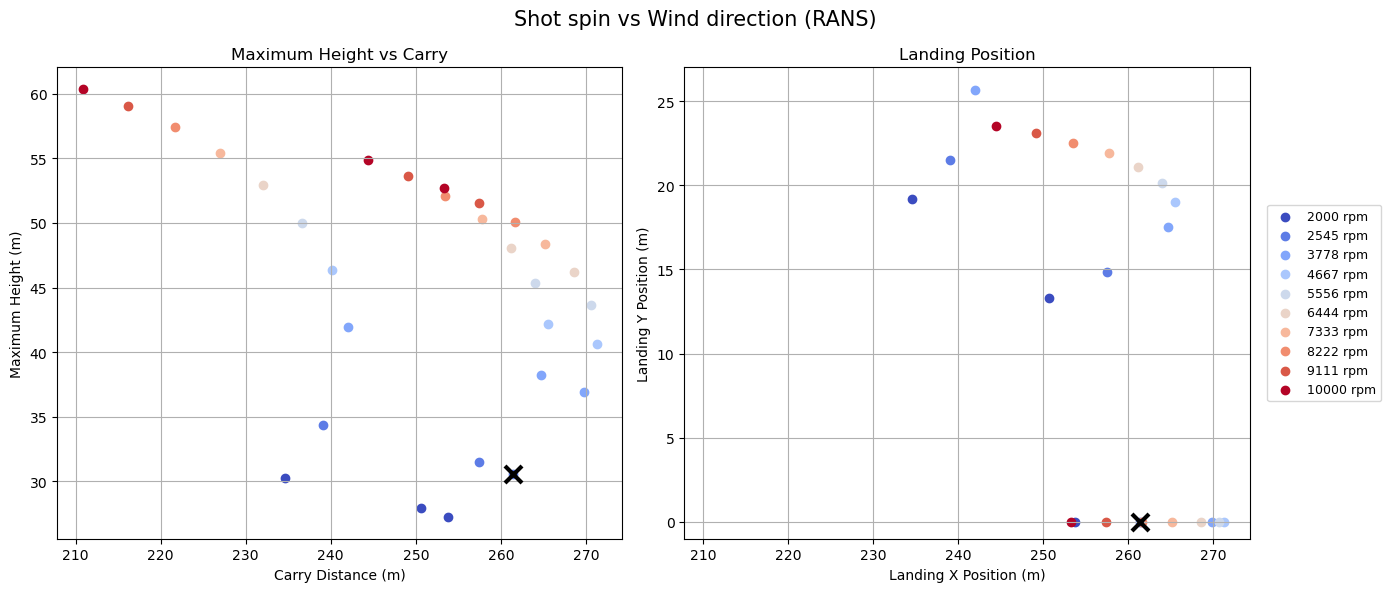

Saved results to: rans_shot_spin_vs_direction.csv


,shot_spin,direction,carry_m,max_height_m,landing_x_m,landing_y_m
0,2000.000000,0,253.739400,27.226708,253.739400,-2.773264e-07
1,2000.000000,270,234.597448,30.284438,234.597448,1.918909e+01
2,2000.000000,315,250.653309,27.973083,250.653309,1.331822e+01
3,2545.000000,0,261.372247,30.602025,261.372247,-2.746859e-07
4,2545.000000,270,239.099167,34.344781,239.099167,2.151508e+01
5,2545.000000,315,257.451258,31.542220,257.451258,1.483671e+01
6,3777.777778,0,269.816159,36.958594,269.816159,-2.590189e-07
7,3777.777778,270,242.038373,41.969141,242.038373,2.564197e+01
8,3777.777778,315,264.681671,38.269242,264.681671,1.753510e+01
9,4666.666667,0,271.259471,40.633054,271.259471,-2.460332e-07


In [ ]:
varying_two_parameters_v3('shot_speed','direction')
varying_two_parameters_v3('shot_angle','direction')
varying_two_parameters_v3('shot_spin','direction')

In [69]:
filepathtester = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0_0.03_mb_cartesian.nc'

shot_speed = 76.44384
shot_angle = 10.4
shot_spin = 2545

U_ref = 6
z0 = 0.03
direction = 0
p_shift = 0

design_n = 10
r = 150

spin_axis = 0
dt = 0.01

wf = WindField(profile='rans', ds=filepathtester, U_ref=U_ref)

traj = Trajectory(
    ball_speed=shot_speed,
    launch_angle=shot_angle,
    spin_rate=shot_spin,
    spin_axis=spin_axis,
    wind=wf,
    orientation=direction,
    P0=np.array([0, 0, 0])
)

traj.solve(solver='euler', dt=dt)
traj.p

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 7.48116457e-01,  0.00000000e+00,  1.38463030e-01],
       [ 1.49266228e+00, -6.04638216e-13,  2.77318448e-01],
       ...,
       [ 2.60235530e+02, -4.64044587e-08,  2.48002433e-01],
       [ 2.60470047e+02, -4.64289883e-08,  7.35661576e-02],
       [ 2.60704481e+02, -4.64534848e-08, -1.01301608e-01]])

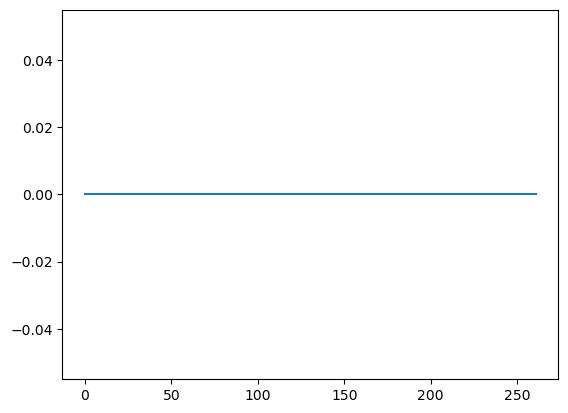

In [72]:
plt.plot(traj.p[:, 0], traj.w[:, 2])